# Hippocampal place cells in rat CA1

## DANDI:000044 — Grosmark & Buzsáki (2016)

A **place cell** is a hippocampal pyramidal neuron that fires selectively when the animal
occupies a particular region of its environment, the cell's *place field*. Together, the
population tiles the environment, so the identity of the currently active cells specifies
where the animal is. This notebook demonstrates the phenomenon end to end on real
extracellular recordings streamed from the DANDI Archive.

**Dataset.** [DANDI:000044](https://dandiarchive.org/dandiset/000044), *"Diversity in neural
firing dynamics supports both rigid and learned hippocampal sequences"*, contributed by
Andres D. Grosmark and György Buzsáki, NWB conversion by Cody Baker.
Eight sessions of bilateral silicon-probe recordings from dorsal CA1 of four
freely-moving Long-Evans rats. Each session is a pre-run sleep epoch, a maze epoch in which
the rat shuttles back and forth on a track for water reward, and a post-run sleep epoch.
Spikes are already sorted and labelled as putative excitatory (pyramidal) or inhibitory
(interneuron) units. Five sessions used a linear track and three a circular maze; because
the linearization used here assumes a straight track, the analysis is scoped to the five
**linear-track** sessions.

**What we show.**

1. Individual CA1 pyramidal cells fire in restricted, reliable portions of the track.
2. Their spatial selectivity greatly exceeds a circular-shift null, whereas simultaneously
   recorded interneurons carry almost no spatial information.
3. Place fields on a linear track are **directional**: the same cell has different fields
   for rightward and leftward traversals.
4. The population tiles the whole track, and position can be decoded from ~1 s of population
   activity to within a few centimetres.
5. A Poisson GLM confirms that position, not running speed, is what the cells encode.

**Access.** Files are streamed with LINDI (a chunk-level index over the remote HDF5) plus a
local cache, so nothing like the full 8 GB per session is ever downloaded.

## 1. Setup

In [1]:
import importlib.util
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter1d
from scipy.signal import medfilt
from scipy.stats import poisson, mannwhitneyu
from tqdm.auto import tqdm

import lindi
import pynapple as nap
import nemos as nmo
from pynwb import NWBHDF5IO

nap.nap_config.suppress_conversion_warnings = True
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

FIGDIR = "."
CACHE_DIR = "./lindi_cache"
os.makedirs(CACHE_DIR, exist_ok=True)


def _notebook_shell():
    """The active IPython shell, or None when running as a plain script."""
    if importlib.util.find_spec("IPython") is None:
        return None
    import IPython
    return IPython.get_ipython()


def savefig(fig, name):
    """Save a figure, and also embed it in the output when running in a notebook.

    Figures are written to disk rather than shown, so the script runs unattended under a
    non-interactive backend. Embedding the saved PNG keeps the notebook readable without
    depending on which matplotlib backend is active.
    """
    path = os.path.join(FIGDIR, name)
    fig.savefig(path, bbox_inches="tight")
    print("saved", path)
    shell = _notebook_shell()
    if shell is not None:
        import IPython.display
        IPython.display.display(IPython.display.Image(filename=path))
    plt.close(fig)
    return path

### Sessions

Asset identifiers for the eight files of the dandiset. LINDI reference files for DANDI assets
are served by neurosift at a predictable URL.

In [2]:
DANDISET = "000044"
LINDI_TEMPLATE = "https://lindi.neurosift.org/dandi/dandisets/{d}/assets/{a}/nwb.lindi.json"

ALL_SESSIONS = [
    ("5349c68b-c0a7-46c0-9900-cda050722fa4", "Achilles", "Achilles_10252013", "1.6m linear"),
    ("8855c8cc-9d8b-4d5b-8ef0-fe87916f839a", "Achilles", "Achilles_11012013", "circular"),
    ("82714afb-724f-4e2b-b102-c9c47b5cba73", "Buddy", "Buddy_06272013", "1.6m linear"),
    ("3cc5b7b3-02e2-490a-9f19-d20670355084", "Cicero", "Cicero_09012014", "1.6m linear"),
    ("f61dfe09-3db2-464a-b386-2e828b2e7276", "Cicero", "Cicero_09102014", "circular"),
    ("e381ebb3-128e-4f3f-9517-11277d7aed9b", "Cicero", "Cicero_09172014", "2m linear"),
    ("31ea0aab-4777-424e-9a93-9605b2bdcc29", "Gatsby", "Gatsby_08022013", "1.6m linear"),
    ("f7687af7-3bc9-4d20-8d88-ef293d2a3381", "Gatsby", "Gatsby_08282013", "circular"),
]
SESSIONS = [s for s in ALL_SESSIONS if "linear" in s[3]]
EXAMPLE = SESSIONS[0]  # Achilles_10252013, the session with the most units

print(f"{len(ALL_SESSIONS)} sessions in the dandiset, {len(SESSIONS)} on a linear track")
for s in SESSIONS:
    print("   ", s[2], "-", s[3])

8 sessions in the dandiset, 5 on a linear track
    Achilles_10252013 - 1.6m linear
    Buddy_06272013 - 1.6m linear
    Cicero_09012014 - 1.6m linear
    Cicero_09172014 - 2m linear
    Gatsby_08022013 - 1.6m linear


In [3]:
def open_nwb(asset_id):
    """Stream one asset of the dandiset through LINDI with a local chunk cache."""
    url = LINDI_TEMPLATE.format(d=DANDISET, a=asset_id)
    f = lindi.LindiH5pyFile.from_lindi_file(url, local_cache=lindi.LocalCache(cache_dir=CACHE_DIR))
    io = NWBHDF5IO(file=f, mode="r")
    return io.read(), io


nwbfile, io = open_nwb(EXAMPLE[0])
print("session_id :", nwbfile.session_id)
print("subject    :", nwbfile.subject.subject_id, "|", nwbfile.subject.species)
print("lab        :", nwbfile.lab, "/", nwbfile.institution)
print("epochs     :", list(nwbfile.intervals["epochs"].to_dataframe().label))
print("behavior   :", list(nwbfile.processing["behavior"].data_interfaces))
print("ecephys    :", list(nwbfile.processing["ecephys"].data_interfaces))
print("units      :", len(nwbfile.units), nwbfile.units.colnames)
print()
print(nap.NWBFile(nwbfile))

session_id : Achilles_10252013
subject    : Achilles | Rattus norvegicus domestica - Long Evans
lab        : Buzsaki / NYU
epochs     : ['PREEpoch', 'MazeEpoch', 'POSTEpoch']
behavior   : ['1.6mLinearMazeLinearizedPosition', '1.6mLinearMazePosition', 'states']
ecephys    : ['LFP']
units      : 137 ('location', 'shank_id', 'cell_type', 'spike_times')

Achilles_10252013
┍━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys                               │ Type        │
┝━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units                              │ TsGroup     │
│ epochs                             │ IntervalSet │
│ LFP                                │ TsdFrame    │
│ states                             │ IntervalSet │
│ 1.6mLinearMazeSpatialSeries        │ TsdFrame    │
│ 1.6mLinearMazeLinearizedTimeSeries │ TsdFrame    │
┕━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙


## 2. Two quirks of these NWB files

Both behavioural `SpatialSeries` objects declare a `rate` of `0.0256`. That number is the
sampling **period** in seconds (39.06 Hz), not a rate, so PyNWB reconstructs timestamps
1525× too sparse and the 2067 s maze epoch appears to span 36 days. Rebuilding the
timestamps as `starting_time + arange(n) * rate` puts the last sample exactly one frame
before the end of the maze epoch, which confirms the interpretation.

The file also ships a linearized position series, but it is defined on only 7–32 % of frames
depending on the session. We recover full coverage by projecting the 2D tracking onto the
principal axis of the track and fitting the affine map to the file's own linearized values
where those exist. The two agree to `r = 1.0000`, so the reconstructed coordinate is in the
dataset's native metric units; it simply also covers the reward platforms at either end,
which the file's linearization omits.

In [4]:
beh = nwbfile.processing["behavior"]
lin_name = next(k for k in beh.data_interfaces if k.endswith("LinearizedPosition"))
pos_name = next(k for k in beh.data_interfaces if k.endswith("Position") and k != lin_name)
ss2d = next(iter(beh[pos_name].spatial_series.values()))
sslin = next(iter(beh[lin_name].spatial_series.values()))

n = ss2d.data.shape[0]
period = ss2d.rate                       # actually the sampling period, in seconds
t_naive = np.asarray(ss2d.timestamps[:]) if ss2d.timestamps is not None else None
t_fixed = ss2d.starting_time + np.arange(n) * period

maze = nwbfile.intervals["epochs"].to_dataframe().query("label == 'MazeEpoch'").iloc[0]
print(f"declared 'rate'      : {period:.8f}  ->  {1/period:.4f} Hz once read as a period")
print(f"MazeEpoch            : {maze.start_time:.1f} - {maze.stop_time:.1f} s "
      f"({maze.stop_time - maze.start_time:.1f} s)")
print(f"PyNWB timestamps end : {ss2d.starting_time + (n-1)/period:,.0f} s   (36 days!)")
print(f"corrected end        : {t_fixed[-1]:.1f} s   "
      f"(residual {t_fixed[-1] - maze.stop_time:+.3f} s = one frame)")

declared 'rate'      : 0.02559991  ->  39.0626 Hz once read as a period
MazeEpoch            : 18079.5 - 20147.0 s (2067.5 s)
PyNWB timestamps end : 3,172,817 s   (36 days!)
corrected end        : 20147.0 s   (residual -0.026 s = one frame)


## 3. Loading and preprocessing

The helpers below turn a raw asset into everything the analysis needs: a linearized position
trace in metres, running speed, lap epochs split by direction of travel, and spike trains as
a pynapple `TsGroup` carrying the cell-type labels.

In [5]:
PERP_TOLERANCE = 0.15    # m, half-width of the accepted corridor around the track axis
SPEED_THRESHOLD = 0.10   # m/s
POS_SMOOTH_STD = 0.10    # s, Gaussian std applied before differentiating position
MIN_RUN_DURATION = 0.5   # s
N_POSITION_BINS = 40


def corrected_timestamps(spatial_series):
    """Rebuild SpatialSeries timestamps, reading `rate` as the sampling period."""
    n = spatial_series.data.shape[0]
    period = spatial_series.rate
    return spatial_series.starting_time + np.arange(n) * period, 1.0 / period


def linearize(xy, file_linear):
    """Project 2D tracking onto the track axis, in the file's own metric units.

    The origin is placed at the far end of one reward platform, so the coordinate spans
    somewhat more than the nominal track length: the extra is the two platforms, where the
    rat waits between traversals.
    """
    finite2d = np.isfinite(xy).all(axis=1)
    known = finite2d & np.isfinite(file_linear)

    ref = xy[known]
    mu = ref.mean(axis=0)
    _, _, vt = np.linalg.svd(ref - mu, full_matrices=False)
    along, across = vt[0], vt[1]
    with np.errstate(all="ignore"):
        proj = (xy - mu) @ along
        perp = (xy - mu) @ across

    slope, intercept = np.polyfit(proj[known], file_linear[known], 1)
    linear = slope * proj + intercept

    # The rat is also tracked in a holding area well off the track axis
    perp0 = np.median(perp[known])
    on_axis = finite2d & (np.abs(perp - perp0) < PERP_TOLERANCE)

    lo, hi = np.percentile(linear[on_axis], [0.2, 99.8])
    linear = linear - lo
    extent = hi - lo
    on_track = on_axis & (linear > -0.02) & (linear < extent + 0.02)
    return np.clip(linear, 0.0, extent), on_track, dict(
        slope=slope, intercept=intercept, extent=extent, perp=perp, perp0=perp0,
        proj=proj, known=known, along=along, mu=mu)


def fill_short_gaps(values, max_gap_samples):
    """Linearly interpolate over NaN runs no longer than `max_gap_samples`."""
    out = values.copy()
    bad = ~np.isfinite(out)
    if not bad.any():
        return out
    idx = np.arange(len(out))
    filled = np.interp(idx, idx[~bad], out[~bad])
    edges = np.diff(np.concatenate([[0], bad.astype(np.int8), [0]]))
    for s, e in zip(np.where(edges == 1)[0], np.where(edges == -1)[0]):
        if (e - s) <= max_gap_samples and s > 0 and e < len(out):
            out[s:e] = filled[s:e]
    return out


def valid_blocks(t, dt, tol=1.5):
    """Index bounds of stretches of `t` sampled at ~dt without gaps."""
    breaks = np.where(np.diff(t) > tol * dt)[0]
    return list(zip(np.concatenate([[0], breaks + 1]),
                    np.concatenate([breaks + 1, [len(t)]])))


def smooth_per_block(values, blocks, std_samples):
    """Median-filter then Gaussian-smooth each contiguous block, with edge replication.

    Doing this per block matters: pynapple's `Tsd.smooth` zero-pads, which manufactures
    metres-per-second velocities at every block boundary.
    """
    out = np.empty_like(values)
    for s, e in blocks:
        seg = values[s:e]
        if len(seg) >= 5:
            seg = medfilt(seg, 5)
        out[s:e] = gaussian_filter1d(seg, std_samples, mode="nearest")
    return out


def contiguous_epochs(t, mask, dt, max_gap_samples=2, min_duration=0.3):
    """IntervalSet covering runs of consecutive True samples in `mask`."""
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return nap.IntervalSet(start=[], end=[])
    breaks = np.where(np.diff(idx) > max_gap_samples)[0]
    starts = np.concatenate([[idx[0]], idx[breaks + 1]])
    ends = np.concatenate([idx[breaks], [idx[-1]]])
    s, e = t[starts], t[ends] + dt
    keep = (e - s) >= min_duration
    return nap.IntervalSet(start=s[keep], end=e[keep])


def load_session(asset_id):
    """Load one session into the objects the place-field analysis needs."""
    nwbfile, io = open_nwb(asset_id)

    epochs_df = nwbfile.intervals["epochs"].to_dataframe()
    maze_row = epochs_df.query("label == 'MazeEpoch'").iloc[0]
    maze_ep = nap.IntervalSet(start=maze_row.start_time, end=maze_row.stop_time)

    beh = nwbfile.processing["behavior"]
    lin_name = next(k for k in beh.data_interfaces if k.endswith("LinearizedPosition"))
    pos_name = next(k for k in beh.data_interfaces
                    if k.endswith("Position") and k != lin_name)
    ss2d = next(iter(beh[pos_name].spatial_series.values()))
    sslin = next(iter(beh[lin_name].spatial_series.values()))

    t, fs = corrected_timestamps(ss2d)
    dt = 1.0 / fs
    xy = np.asarray(ss2d.data[:])
    file_linear = np.asarray(sslin.data[:]).ravel()

    linear, on_track, lin_info = linearize(xy, file_linear)

    # Fill dropouts up to ~0.75 s so single traversals are not fragmented
    filled = fill_short_gaps(np.where(on_track, linear, np.nan), int(0.75 * fs))
    valid = np.isfinite(filled)
    pos_ep = contiguous_epochs(t, valid, dt, max_gap_samples=1, min_duration=0.5)

    position = nap.Tsd(t=t[valid], d=filled[valid], time_support=pos_ep).restrict(pos_ep)
    xy_filled = np.column_stack([fill_short_gaps(np.where(on_track, xy[:, i], np.nan),
                                                 int(0.75 * fs)) for i in range(2)])
    xy_tsd = nap.TsdFrame(t=t[valid], d=xy_filled[valid], columns=["x", "y"],
                          time_support=pos_ep).restrict(pos_ep)

    smoothed = nap.Tsd(t=position.t,
                       d=smooth_per_block(position.values,
                                          valid_blocks(position.t, dt),
                                          POS_SMOOTH_STD * fs),
                       time_support=pos_ep)
    velocity = smoothed.derivative()
    speed = nap.Tsd(t=velocity.t, d=np.abs(velocity.values), time_support=pos_ep)

    # Spike times are not sorted within every unit of every file
    units = nwbfile.units
    spikes = nap.TsGroup(
        {i: nap.Ts(t=np.sort(np.asarray(units["spike_times"][i]))) for i in range(len(units))},
        time_support=nap.IntervalSet(start=epochs_df.start_time.min(),
                                     end=epochs_df.stop_time.max()),
    )
    spikes.set_info(
        cell_type=np.asarray(units["cell_type"][:]).astype(str),
        location=np.asarray(units["location"][:]).astype(str),
        shank_id=np.asarray(units["shank_id"][:]),
    )

    return dict(session_id=nwbfile.session_id, subject=nwbfile.subject.subject_id,
                nwbfile=nwbfile, io=io, epochs=epochs_df, maze_ep=maze_ep,
                states=beh["states"].to_dataframe(), position=position, xy=xy_tsd,
                velocity=velocity, speed=speed, spikes=spikes, fs=fs,
                lin_info=lin_info, pos_ep=pos_ep, extent=lin_info["extent"])

### Lap detection

Rather than thresholding instantaneous speed (which fragments a single traversal every time
the tracking stalls), we split the position trace at midline crossings and take each lap to
run from the rat's final departure from the extreme of one excursion to its first arrival at
the extreme of the next. A lap is kept only if both extremes actually reach the ends of the
track. Within each lap we then keep only the samples where the rat is moving faster than
10 cm/s **in that lap's direction**, which removes pauses and small back-steps.

In [6]:
def lap_epochs(session, end_frac=0.15, max_lap_duration=90.0, max_gap=10.0, tol=0.03):
    """Detect complete end-to-end traversals, split by direction of travel."""
    pos = session["position"]
    t, x = pos.t, pos.values
    extent = session["extent"]
    lo_end, hi_end = end_frac * extent, (1 - end_frac) * extent

    above = (x > 0.5 * extent).astype(np.int8)
    bounds = np.concatenate([[0], np.where(np.diff(above) != 0)[0] + 1, [len(x)]])

    marks = []
    for s, e in zip(bounds[:-1], bounds[1:]):
        seg = x[s:e]
        side = 1 if above[s] else -1
        extreme = seg.max() if side > 0 else seg.min()
        at = np.where(seg >= extreme - tol)[0] if side > 0 else np.where(seg <= extreme + tol)[0]
        marks.append(dict(side=side, extreme=extreme, depart=s + at[-1], arrive=s + at[0]))

    laps = {"rightward": [], "leftward": []}
    for a, b in zip(marks[:-1], marks[1:]):
        if a["side"] == b["side"]:
            continue
        rightward = a["side"] < 0
        reaches_ends = ((a["extreme"] < lo_end and b["extreme"] > hi_end) if rightward
                        else (a["extreme"] > hi_end and b["extreme"] < lo_end))
        if not reaches_ends:
            continue
        i0, i1 = a["depart"], b["arrive"]
        if i1 <= i0:
            continue
        duration = t[i1] - t[i0]
        if not (MIN_RUN_DURATION <= duration <= max_lap_duration):
            continue
        if np.max(np.diff(t[i0:i1 + 1])) > max_gap:
            continue
        laps["rightward" if rightward else "leftward"].append((t[i0], t[i1]))

    eps = {}
    for name, iv in laps.items():
        iv = np.asarray(iv, dtype=float).reshape(-1, 2)
        eps[name] = nap.IntervalSet(start=iv[:, 0], end=iv[:, 1]).intersect(session["pos_ep"])
    eps["both"] = eps["rightward"].union(eps["leftward"])
    eps["n_laps"] = {k: len(v) for k, v in laps.items()}
    return eps


def moving_epochs(session, laps, speed_threshold=SPEED_THRESHOLD):
    """Within-lap epochs where the rat is moving in that lap's direction."""
    vel = session["velocity"]
    dt = 1.0 / session["fs"]
    out = {}
    for name, sign in (("rightward", 1), ("leftward", -1)):
        mask = (np.abs(vel.values) > speed_threshold) & (np.sign(vel.values) == sign)
        # Requiring a third of a second rejects the brief wiggles the rat makes
        # while waiting at a reward platform.
        consistent = contiguous_epochs(vel.t, mask, dt, max_gap_samples=8, min_duration=0.3)
        out[name] = laps[name].intersect(consistent)
    out["both"] = out["rightward"].union(out["leftward"])
    return out

In [7]:
sess = load_session(EXAMPLE[0])
laps = lap_epochs(sess)
mov = moving_epochs(sess, laps)

spikes = sess["spikes"]
exc = spikes[np.where(spikes.get_info("cell_type") == "excitatory")[0]]
inh = spikes[np.where(spikes.get_info("cell_type") == "inhibitory")[0]]

print(f"session      : {sess['session_id']} (rat {sess['subject']})")
print(f"tracking      : {sess['fs']:.3f} Hz, track extent {sess['extent']:.2f} m")
print(f"maze epoch    : {float(sess['maze_ep'].end[0] - sess['maze_ep'].start[0]):.0f} s, "
      f"{sess['pos_ep'].tot_length():.0f} s of usable tracking")
print(f"laps          : {laps['n_laps']['rightward']} rightward, "
      f"{laps['n_laps']['leftward']} leftward")
print(f"running time  : {mov['rightward'].tot_length():.0f} s rightward, "
      f"{mov['leftward'].tot_length():.0f} s leftward")
print(f"units         : {len(exc)} excitatory, {len(inh)} inhibitory "
      f"({', '.join(sorted(set(spikes.get_info('location'))))})")

session      : Achilles_10252013 (rat Achilles)
tracking      : 39.063 Hz, track extent 1.97 m
maze epoch    : 2068 s, 1344 s of usable tracking
laps          : 42 rightward, 42 leftward
running time  : 176 s rightward, 145 s leftward
units         : 120 excitatory, 17 inhibitory (lCA1, rCA1)


### Figure 1 — Validating the reconstructed behaviour

Before analysing spikes, check that the behaviour makes sense: the 2D tracking should form a
straight track, the linearization should reproduce the file's own where that exists, and the
detected laps should line up with the visible traversals.

saved ./fig01_behaviour.png


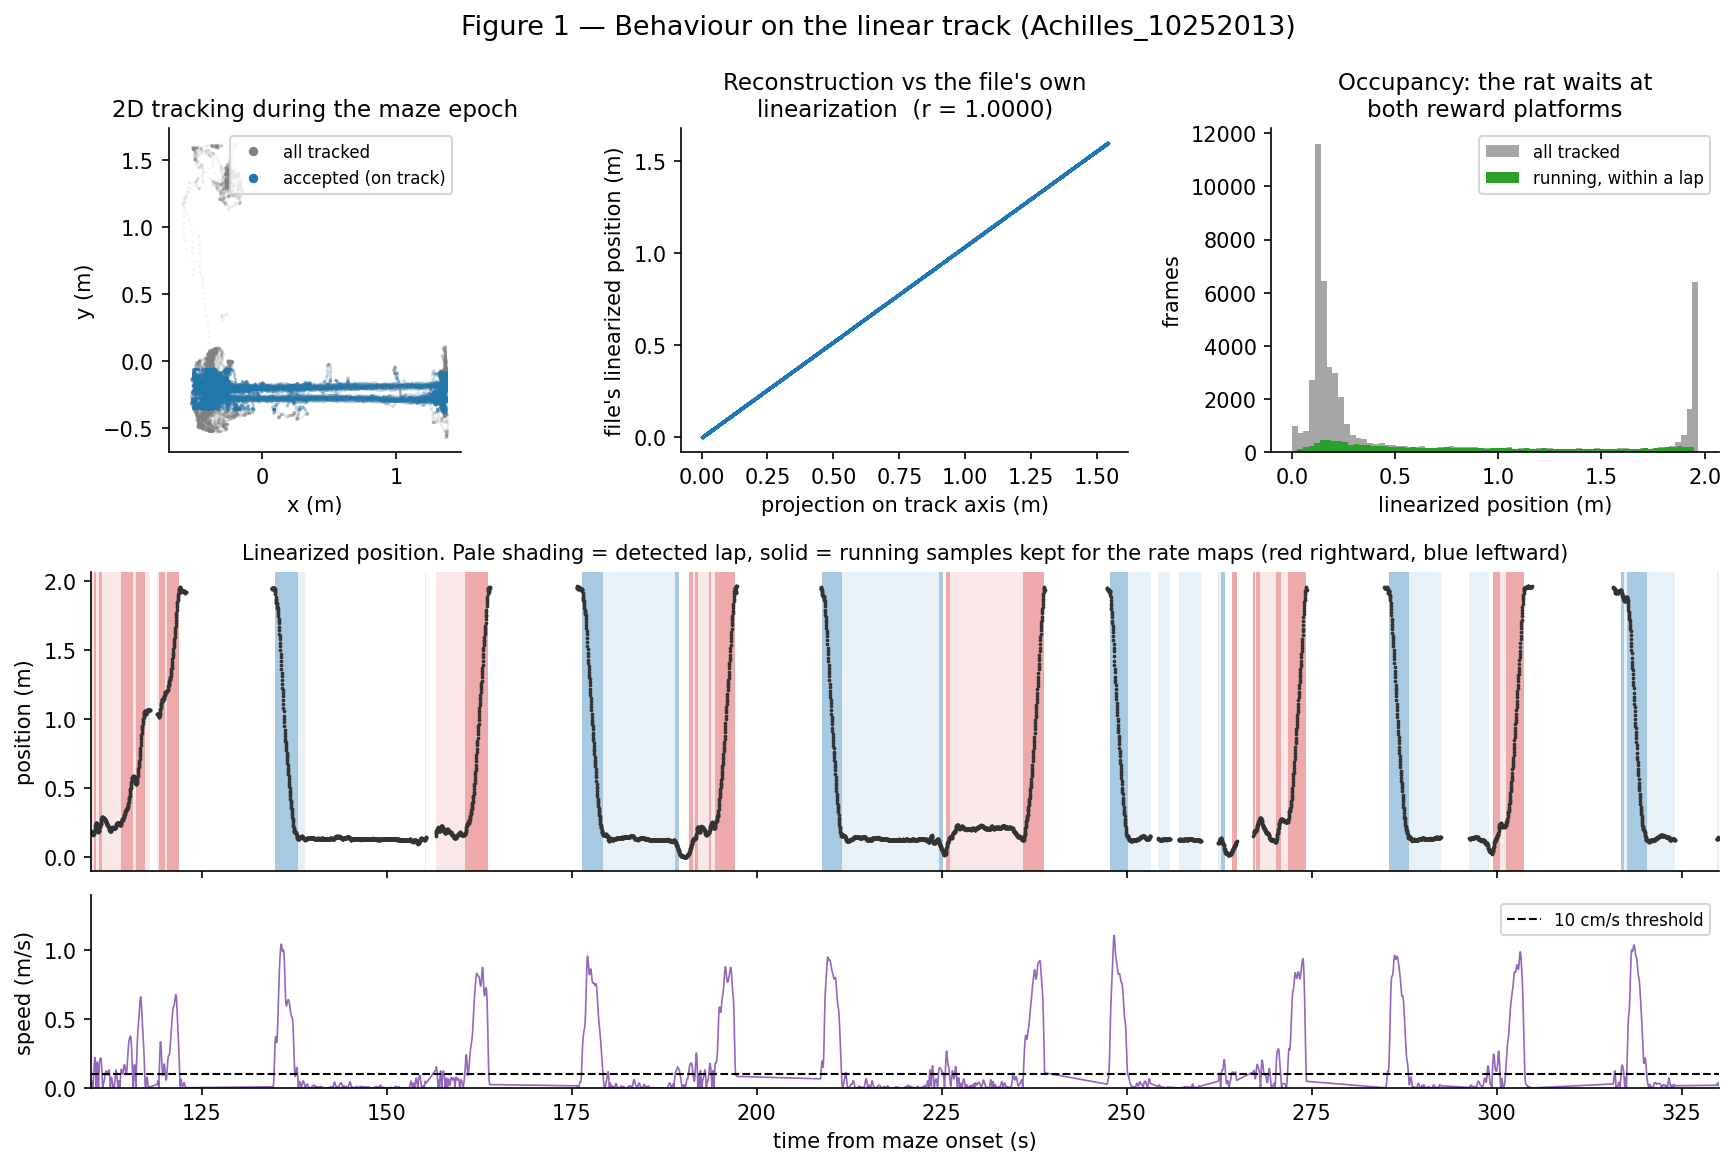

'./fig01_behaviour.png'

In [8]:
info = sess["lin_info"]
xy_all = np.asarray(next(iter(sess["nwbfile"].processing["behavior"][pos_name]
                              .spatial_series.values())).data[:])
lin_file_all = np.asarray(next(iter(sess["nwbfile"].processing["behavior"][lin_name]
                                    .spatial_series.values())).data[:]).ravel()

fig = plt.figure(figsize=(14, 8.0))
gs = GridSpec(1, 3, figure=fig, top=0.87, bottom=0.60, wspace=0.32)
gs_b = GridSpec(2, 1, figure=fig, top=0.50, bottom=0.07, hspace=0.10,
                height_ratios=[1.55, 1.0])

ax = fig.add_subplot(gs[0, 0])
good = np.isfinite(xy_all).all(axis=1)
ax.plot(xy_all[good, 0], xy_all[good, 1], ".", ms=0.7, alpha=0.12, color="0.5",
        label="all tracked")
ax.plot(sess["xy"].values[:, 0], sess["xy"].values[:, 1], ".", ms=0.7, alpha=0.12,
        color="tab:blue", label="accepted (on track)")
ax.set_aspect("equal")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title("2D tracking during the maze epoch")
leg = ax.legend(markerscale=10, fontsize=8, loc="upper right")
for h in leg.legend_handles:
    h.set_alpha(1)

ax = fig.add_subplot(gs[0, 1])
k = info["known"]
ax.plot(info["proj"][k] - info["proj"][k].min(), lin_file_all[k], ".", ms=1, color="tab:blue")
r = np.corrcoef(info["proj"][k], lin_file_all[k])[0, 1]
ax.set_xlabel("projection on track axis (m)")
ax.set_ylabel("file's linearized position (m)")
ax.set_title(f"Reconstruction vs the file's own\nlinearization  (r = {r:.4f})")

ax = fig.add_subplot(gs[0, 2])
ax.hist(sess["position"].values, bins=70, color="0.65", label="all tracked")
ax.hist(sess["position"].restrict(mov["both"]).values, bins=70, color="tab:green",
        label="running, within a lap")
ax.set_xlabel("linearized position (m)"); ax.set_ylabel("frames")
ax.set_title("Occupancy: the rat waits at\nboth reward platforms")
ax.legend(fontsize=8)

t0 = float(sess["maze_ep"].start[0])
win = (110, 330)
ax_pos = fig.add_subplot(gs_b[0, 0])
p = sess["position"]
for d, color in (("rightward", "tab:red"), ("leftward", "tab:blue")):
    for s, e in zip(laps[d].start, laps[d].end):
        ax_pos.axvspan(s - t0, e - t0, color=color, alpha=0.10, lw=0)
    for s, e in zip(mov[d].start, mov[d].end):
        ax_pos.axvspan(s - t0, e - t0, color=color, alpha=0.32, lw=0)
ax_pos.plot(p.t - t0, p.values, ".", ms=1.6, color="0.2")
ax_pos.set_xlim(*win)
ax_pos.set_ylabel("position (m)")
ax_pos.set_title("Linearized position. Pale shading = detected lap, solid = running samples "
                 "kept for the rate maps (red rightward, blue leftward)", pad=6, fontsize=10)
ax_pos.tick_params(labelbottom=False)

ax = fig.add_subplot(gs_b[1, 0], sharex=ax_pos)
ax.plot(sess["speed"].t - t0, sess["speed"].values, lw=0.8, color="tab:purple")
ax.axhline(SPEED_THRESHOLD, color="k", ls="--", lw=1,
           label=f"{SPEED_THRESHOLD*100:.0f} cm/s threshold")
ax.set_xlim(*win); ax.set_ylim(0, 1.4)
ax.set_xlabel("time from maze onset (s)"); ax.set_ylabel("speed (m/s)")
ax.legend(fontsize=8, loc="upper right")

fig.suptitle(f"Figure 1 — Behaviour on the linear track ({sess['session_id']})",
             y=0.965, fontsize=13)
savefig(fig, "fig01_behaviour.png")

## 4. Place fields

A place field is estimated as a firing-rate map: spike counts per 5 cm position bin divided
by the time the rat spent in that bin, smoothed with a one-bin Gaussian, computed separately
for rightward and leftward laps and using only the running samples defined above.

Significance is assessed against a **circular-shift null**. Each unit's spike train is
circularly shifted along the concatenated stream of running samples, which destroys the
spike-position relationship while preserving the train's own firing-rate and burst
statistics. Spatial selectivity is quantified with Skaggs information,

$$I = \sum_x p(x)\,\frac{\lambda(x)}{\bar\lambda}\,\log_2 \frac{\lambda(x)}{\bar\lambda}
\quad\text{bits per spike,}$$

where $p(x)$ is occupancy, $\lambda(x)$ the rate map and $\bar\lambda$ the mean rate.

In [9]:
def binned(spikes, position, ep, extent, bins):
    """Align spikes to the position samples inside `ep` (concatenated across epochs)."""
    pos = position.restrict(ep)
    edges = np.linspace(0.0, extent, bins + 1)
    bin_idx = np.clip(np.digitize(pos.values, edges) - 1, 0, bins - 1)
    t = pos.t
    counts = np.zeros((len(spikes), len(t)), dtype=np.int32)
    for row, uid in enumerate(spikes.keys()):
        st = spikes[uid].restrict(ep).t
        if len(st):
            np.add.at(counts[row], np.clip(np.searchsorted(t, st), 0, len(t) - 1), 1)
    return bin_idx, counts, edges


def rate_maps(bin_idx, counts, occupancy, smooth_bins=1.0):
    nbins = len(occupancy)
    maps = np.stack([np.bincount(bin_idx, weights=c, minlength=nbins) for c in counts])
    maps = np.nan_to_num(maps / occupancy[None, :])
    return gaussian_filter1d(maps, smooth_bins, axis=-1, mode="nearest") if smooth_bins else maps


def skaggs_information(maps, occupancy):
    """Skaggs spatial information in bits/spike for each row of `maps`."""
    p = occupancy / occupancy.sum()
    mean_rate = (p[None, :] * maps).sum(axis=1)
    ratio = maps / mean_rate[:, None]
    term = p[None, :] * ratio * np.log2(ratio)
    return np.nansum(np.where(maps > 0, term, 0.0), axis=1)


def spatial_info_with_shuffle(spikes, position, ep, extent, fs, bins=N_POSITION_BINS,
                              n_shuffles=500, smooth_bins=1.0, seed=0, progress=True):
    bin_idx, counts, edges = binned(spikes, position, ep, extent, bins)
    occupancy = np.bincount(bin_idx, minlength=bins) / fs
    occupancy[occupancy == 0] = np.nan

    maps = rate_maps(bin_idx, counts, occupancy, smooth_bins)
    si = skaggs_information(maps, np.nan_to_num(occupancy))

    rng = np.random.default_rng(seed)
    n_samples = counts.shape[1]
    min_shift = max(1, min(int(20 * fs), n_samples // 4))
    null = np.empty((n_shuffles, len(spikes)))
    for i in tqdm(range(n_shuffles), desc="shuffles", leave=False, disable=not progress):
        shifts = rng.integers(min_shift, n_samples - min_shift, size=len(spikes))
        shifted = np.stack([np.roll(c, s) for c, s in zip(counts, shifts)])
        null[i] = skaggs_information(rate_maps(bin_idx, shifted, occupancy, smooth_bins),
                                     np.nan_to_num(occupancy))
    return dict(maps=maps, si=si, null=null,
                pvals=(null >= si[None, :]).sum(axis=0) / n_shuffles,
                occupancy=occupancy, edges=edges,
                centers=0.5 * (edges[:-1] + edges[1:]), n_spikes=counts.sum(axis=1),
                unit_ids=np.asarray(list(spikes.keys())))


def split_half_stability(spikes, position, ep, extent, fs, bins=N_POSITION_BINS,
                         smooth_bins=1.0):
    """Correlation between rate maps built from alternate (odd / even) laps."""
    idx = np.arange(len(ep))
    halves = []
    for sel in (idx[0::2], idx[1::2]):
        bin_idx, counts, _ = binned(spikes, position, ep[sel], extent, bins)
        occ = np.bincount(bin_idx, minlength=bins) / fs
        occ[occ == 0] = np.nan
        halves.append(rate_maps(bin_idx, counts, occ, smooth_bins))
    a, b = halves
    ok = np.isfinite(a) & np.isfinite(b)
    r = np.array([
        np.corrcoef(a[i][ok[i]], b[i][ok[i]])[0, 1]
        if ok[i].sum() > 3 and a[i][ok[i]].std() > 0 and b[i][ok[i]].std() > 0 else np.nan
        for i in range(a.shape[0])])
    return r, a, b

### Place-cell criteria

A unit counts as a place cell in a given direction if it is a putative excitatory cell that

* fires at least 50 spikes during running in that direction,
* reaches a peak rate of at least 1 Hz,
* carries more Skaggs information than 95 % of its circular-shift null, and
* has a split-half (odd vs even lap) rate-map correlation above 0.5.

In [10]:
PLACE_CELL_MIN_PEAK = 1.0
PLACE_CELL_MIN_SPIKES = 50
PLACE_CELL_MIN_STABILITY = 0.5
PLACE_CELL_ALPHA = 0.05


def classify_place_cells(res):
    return ((res["pvals"] < PLACE_CELL_ALPHA)
            & (res["maps"].max(axis=1) >= PLACE_CELL_MIN_PEAK)
            & (res["n_spikes"] >= PLACE_CELL_MIN_SPIKES)
            & (np.nan_to_num(res["stability"], nan=-1) > PLACE_CELL_MIN_STABILITY))


def field_metrics(res):
    """Peak rate, peak position and field width (bins above half the peak)."""
    maps, centers = res["maps"], res["centers"]
    peak_rate = maps.max(axis=1)
    peak_pos = centers[maps.argmax(axis=1)]
    bin_w = centers[1] - centers[0]
    width = (maps >= 0.5 * peak_rate[:, None]).sum(axis=1) * bin_w
    return peak_rate, peak_pos, width


def analyze_session(asset_id, n_shuffles=500, seed=0, progress=True):
    sess = load_session(asset_id)
    laps = lap_epochs(sess)
    mov = moving_epochs(sess, laps)
    ctype = sess["spikes"].get_info("cell_type")
    exc = sess["spikes"][np.where(ctype == "excitatory")[0]]
    inh = sess["spikes"][np.where(ctype == "inhibitory")[0]]

    out = dict(session=sess, laps=laps, moving=mov, exc=exc, inh=inh, directions={})
    for d in ("rightward", "leftward"):
        res = spatial_info_with_shuffle(exc, sess["position"], mov[d], sess["extent"],
                                        sess["fs"], n_shuffles=n_shuffles, seed=seed,
                                        progress=progress)
        res["stability"], res["half_a"], res["half_b"] = split_half_stability(
            exc, sess["position"], mov[d], sess["extent"], sess["fs"])
        res["is_place_cell"] = classify_place_cells(res)
        out["directions"][d] = res

    res_inh = spatial_info_with_shuffle(inh, sess["position"], mov["rightward"],
                                        sess["extent"], sess["fs"],
                                        n_shuffles=n_shuffles, seed=seed, progress=progress)
    res_inh["stability"], _, _ = split_half_stability(inh, sess["position"], mov["rightward"],
                                                      sess["extent"], sess["fs"])
    out["inhibitory"] = res_inh
    out["is_place_cell_any"] = (out["directions"]["rightward"]["is_place_cell"]
                                | out["directions"]["leftward"]["is_place_cell"])
    return out

In [11]:
analysis = analyze_session(EXAMPLE[0], n_shuffles=500)
res_r = analysis["directions"]["rightward"]
res_l = analysis["directions"]["leftward"]
pc_any = analysis["is_place_cell_any"]

summary = pd.DataFrame({
    "rightward": [res_r["is_place_cell"].sum(), np.median(res_r["si"]),
                  np.percentile(res_r["null"], 95), np.nanmedian(res_r["stability"]),
                  np.median(res_r["maps"].max(axis=1))],
    "leftward": [res_l["is_place_cell"].sum(), np.median(res_l["si"]),
                 np.percentile(res_l["null"], 95), np.nanmedian(res_l["stability"]),
                 np.median(res_l["maps"].max(axis=1))],
}, index=["place cells", "median SI (bits/spike)", "95th pct of null SI",
          "median split-half r", "median peak rate (Hz)"]).round(3)
print(summary.to_string())
print()
print(f"place cells in either direction: {pc_any.sum()} / {len(exc)} excitatory units "
      f"({100*pc_any.mean():.0f}%)")
print(f"place cells in both directions : "
      f"{(res_r['is_place_cell'] & res_l['is_place_cell']).sum()}")
print(f"interneurons, median SI        : {np.median(analysis['inhibitory']['si']):.3f} "
      f"bits/spike (vs {np.median(res_r['si']):.3f} for pyramidal cells)")

shuffles:   0%|          | 0/500 [00:00<?, ?it/s]

shuffles:   0%|          | 0/500 [00:00<?, ?it/s]

shuffles:   0%|          | 0/500 [00:00<?, ?it/s]

                        rightward  leftward
place cells                76.000    78.000
median SI (bits/spike)      0.786     0.905
95th pct of null SI         0.833     0.918
median split-half r         0.800     0.858
median peak rate (Hz)       3.791     3.915

place cells in either direction: 97 / 120 excitatory units (81%)
place cells in both directions : 57
interneurons, median SI        : 0.032 bits/spike (vs 0.786 for pyramidal cells)


### Figure 2 — Single place cells

For six example cells: the lap-by-lap spike raster (each row a traversal, each dot a spike
plotted at the rat's position) and the corresponding rate maps for both directions. The
shaded band is the 5th–95th percentile of the circular-shift null.

example units: [ 95  24 107  25 110  56] peaks at [0.17 0.47 0.86 1.16 1.5  1.89] m


/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/base_class.py:50: UserWarning: Some epochs have no duration
  self.time_support = IntervalSet(start=self.index[0], end=self.index[-1])


saved ./fig02_example_place_cells.png


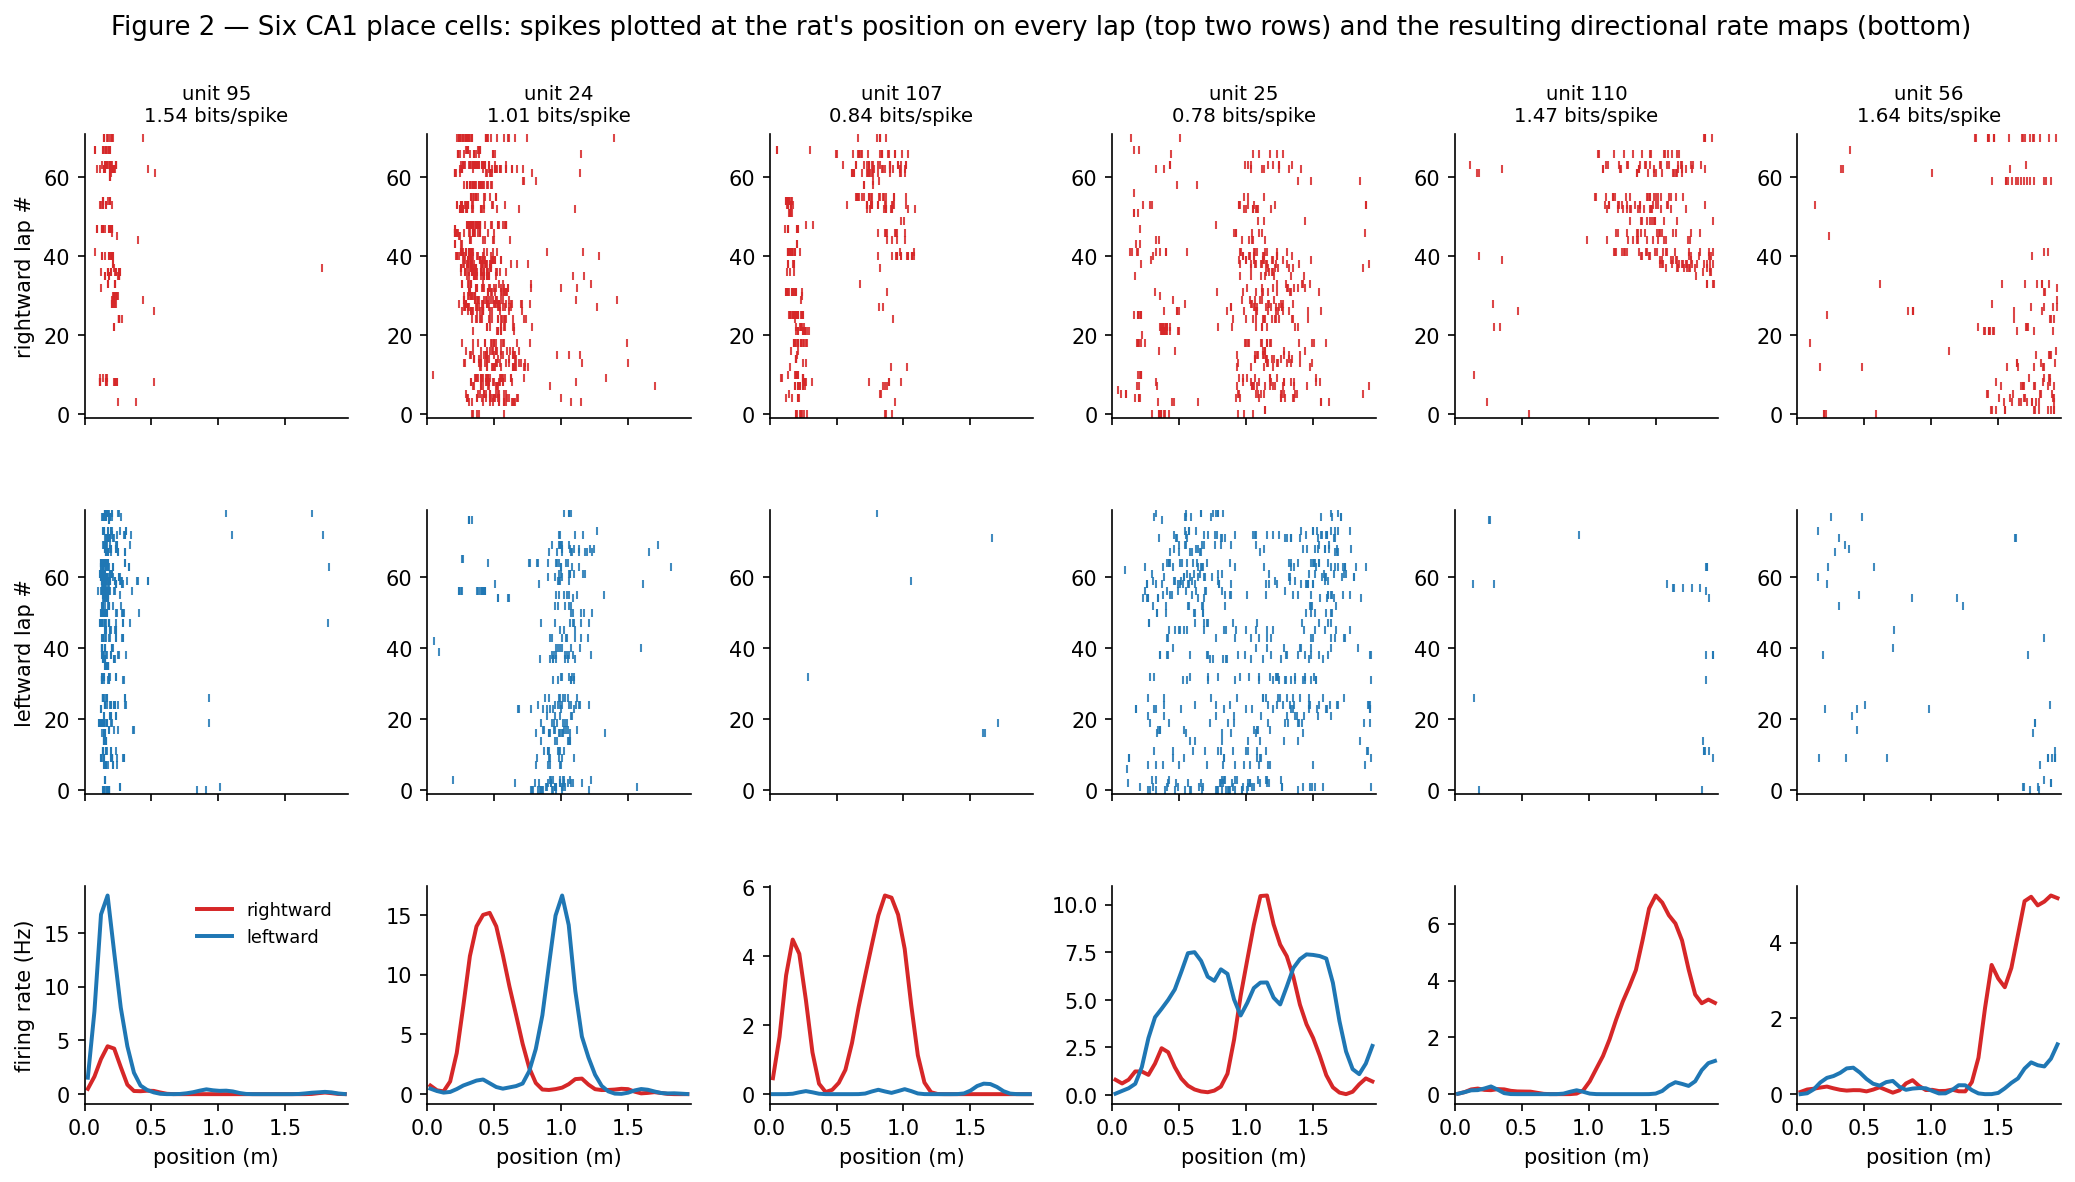

'./fig02_example_place_cells.png'

In [12]:
def spike_positions_by_lap(spikes, uid, position, lap_ep, keep_ep):
    """(position, lap index) of every spike this unit fired while running in each lap."""
    xs, ys = [], []
    for i in range(len(lap_ep)):
        window = lap_ep[i].intersect(keep_ep)
        if len(window) == 0:
            continue
        st = spikes[uid].restrict(window).t
        if len(st):
            xs.append(position.interpolate(nap.Ts(st), ep=window).values)
            ys.append(np.full(len(st), i))
    if not xs:
        return np.array([]), np.array([])
    return np.concatenate(xs), np.concatenate(ys)


def pick_examples(res, extent, n=6, min_si=0.6):
    """Place cells whose fields sit closest to n evenly spaced positions."""
    peak = res["centers"][res["maps"].argmax(axis=1)]
    ok = np.where(res["is_place_cell"] & (res["si"] > min_si))[0]
    targets = np.linspace(0.08, 0.92, n) * extent
    chosen = []
    for tgt in targets:
        avail = [j for j in ok if j not in chosen]
        chosen.append(avail[int(np.argmin(np.abs(peak[avail] - tgt)))])
    return np.array(chosen)


examples = pick_examples(res_r, sess["extent"], n=6)
example_uids = res_r["unit_ids"][examples]
print("example units:", example_uids,
      "peaks at", np.round(res_r["centers"][res_r["maps"][examples].argmax(axis=1)], 2), "m")

fig, axs = plt.subplots(3, 6, figsize=(17, 8.4),
                        gridspec_kw=dict(height_ratios=[1.3, 1.3, 1.0], hspace=0.35, wspace=0.3))
for col, (j, uid) in enumerate(zip(examples, example_uids)):
    for row, (d, color) in enumerate([("rightward", "tab:red"), ("leftward", "tab:blue")]):
        ax = axs[row, col]
        x, y = spike_positions_by_lap(exc, uid, sess["position"], laps[d], mov[d])
        ax.plot(x, y, "|", ms=3.5, color=color, alpha=0.85)
        ax.set_xlim(0, sess["extent"])
        ax.set_ylim(-1, len(laps[d]))
        if col == 0:
            ax.set_ylabel(f"{d} lap #")
        ax.tick_params(labelbottom=False)
        if row == 0:
            ax.set_title(f"unit {uid}\n{res_r['si'][j]:.2f} bits/spike", fontsize=9.5)

    ax = axs[2, col]
    for d, res, color in [("rightward", res_r, "tab:red"), ("leftward", res_l, "tab:blue")]:
        ax.plot(res["centers"], res["maps"][j], color=color, lw=1.9, label=d)
    ax.set_xlim(0, sess["extent"])
    ax.set_xlabel("position (m)")
    if col == 0:
        ax.set_ylabel("firing rate (Hz)")
        ax.legend(fontsize=8.5, frameon=False)

fig.suptitle("Figure 2 — Six CA1 place cells: spikes plotted at the rat's position on every "
             "lap (top two rows) and the resulting directional rate maps (bottom)",
             y=0.975, fontsize=12.5)
savefig(fig, "fig02_example_place_cells.png")

### Figure 3 — The population tiles the track, and does so directionally

Left and centre: every place cell's rate map, peak-normalised, sorted by the location of its
rightward peak. Sorting by the rightward field does *not* order the leftward maps, which is
the classic signature of directional place fields on a linear track. Right: the same sort
applied to a 60 s stretch of raw spiking, where each traversal appears as a sweep through
the population.

saved ./fig03_population.png


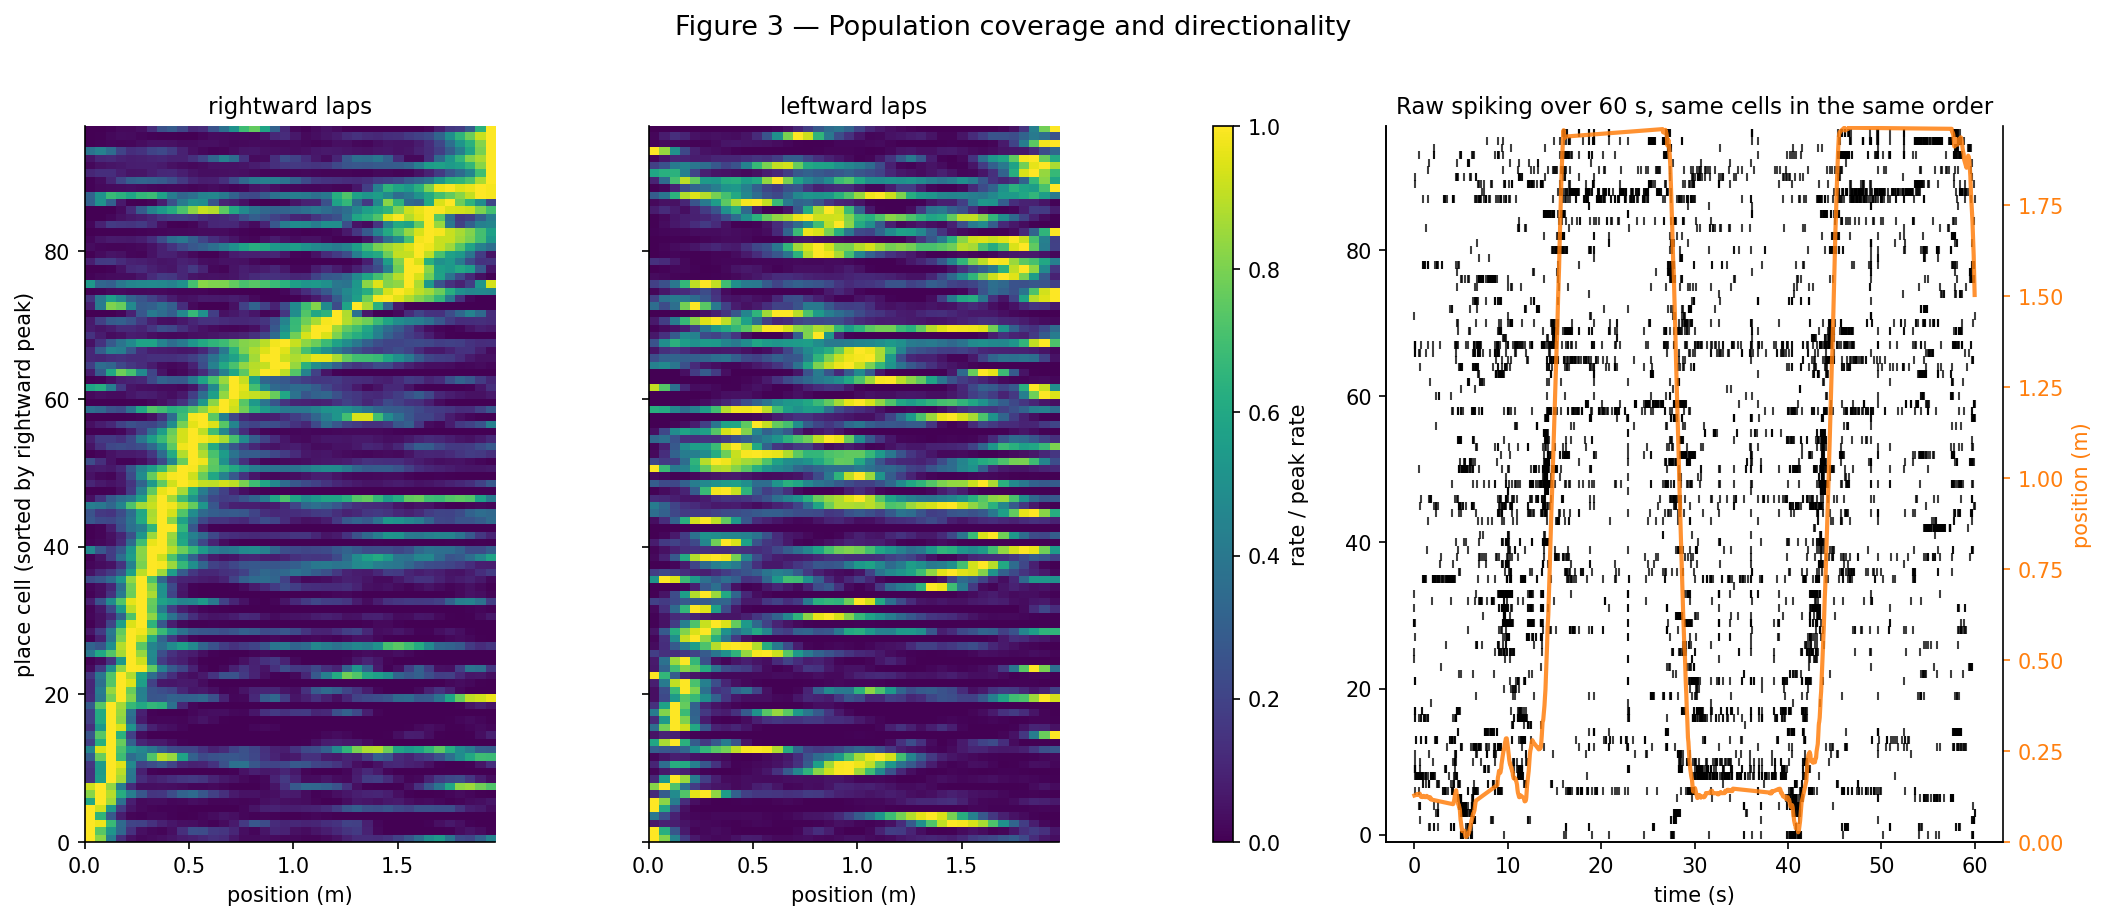

'./fig03_population.png'

In [13]:
pc_idx = np.where(pc_any)[0]
order = pc_idx[np.argsort(res_r["maps"][pc_idx].argmax(axis=1))]


def norm_maps(m):
    peak = m.max(axis=1, keepdims=True)
    return m / np.where(peak > 0, peak, 1)


fig = plt.figure(figsize=(16.5, 6.2))
gs = GridSpec(1, 4, width_ratios=[1, 1, 0.05, 1.5], wspace=0.42)

for k, (d, res) in enumerate([("rightward", res_r), ("leftward", res_l)]):
    ax = fig.add_subplot(gs[0, k])
    im = ax.imshow(norm_maps(res["maps"][order]), aspect="auto", origin="lower",
                   extent=[0, sess["extent"], 0, len(order)], cmap="viridis",
                   vmin=0, vmax=1, interpolation="nearest")
    ax.set_xlabel("position (m)")
    ax.set_ylabel("place cell (sorted by rightward peak)" if k == 0 else "")
    ax.set_title(f"{d} laps")
    if k == 1:
        ax.tick_params(labelleft=False)
        plt.colorbar(im, cax=fig.add_subplot(gs[0, 2]), label="rate / peak rate")

ax = fig.add_subplot(gs[0, 3])
t_start = float(laps["rightward"].start[6])
window = nap.IntervalSet(t_start - 6, t_start + 54)
for row, j in enumerate(order):
    st = exc[res_r["unit_ids"][j]].restrict(window).t
    ax.plot(st - window.start[0], np.full_like(st, row), "|", ms=4, color="k", alpha=0.75)
ax2 = ax.twinx()
p = sess["position"].restrict(window)
ax2.plot(p.t - window.start[0], p.values, color="tab:orange", lw=2, alpha=0.85)
ax2.set_ylabel("position (m)", color="tab:orange")
ax2.tick_params(axis="y", colors="tab:orange")
ax2.set_ylim(0, sess["extent"])
ax2.spines["right"].set_visible(True)
ax.set_xlabel("time (s)")
ax.set_ylim(-1, len(order))
ax.set_title("Raw spiking over 60 s, same cells in the same order")

fig.suptitle("Figure 3 — Population coverage and directionality", y=1.0, fontsize=13)
savefig(fig, "fig03_population.png")

### Figure 4 — Spatial selectivity against the null, and against interneurons

saved ./fig04_statistics.png


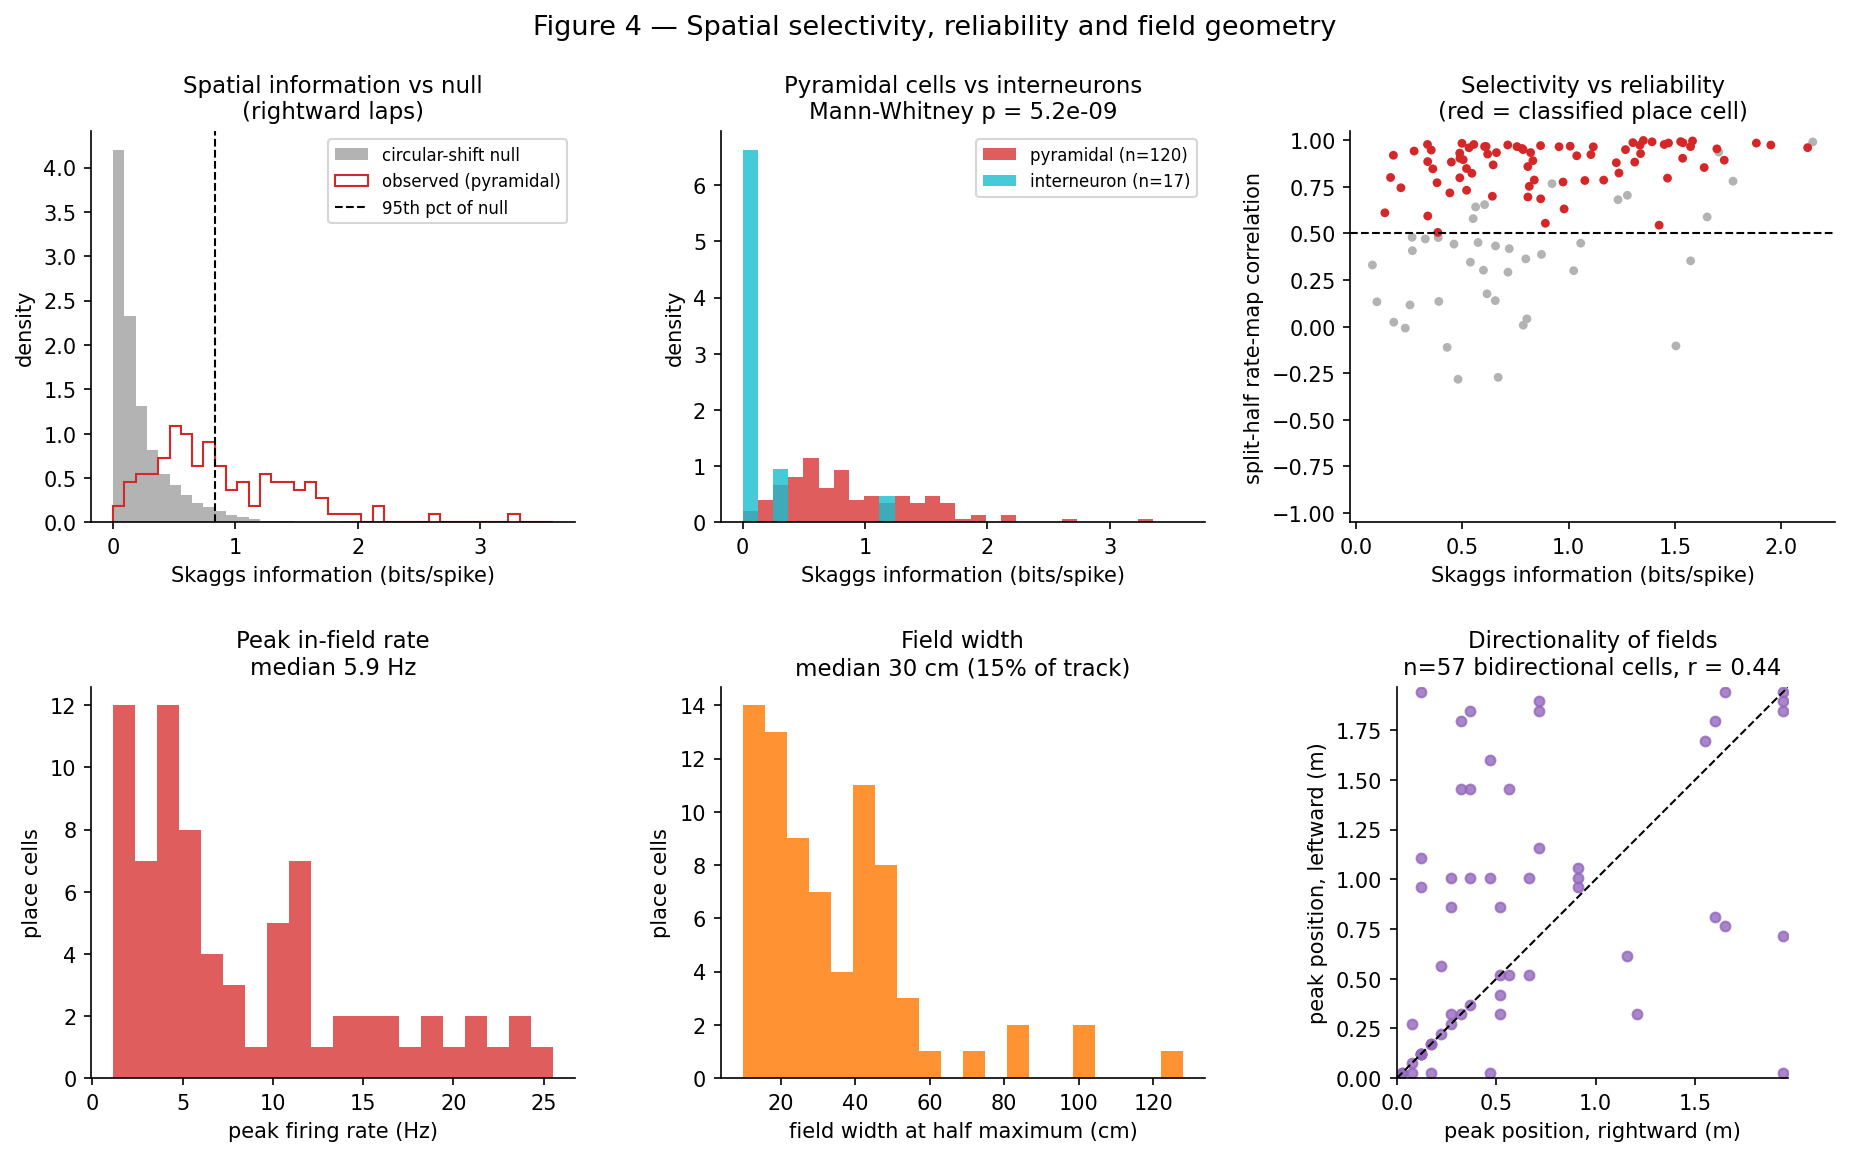

'./fig04_statistics.png'

In [14]:
peak_r, peakpos_r, width_r = field_metrics(res_r)
peak_l, peakpos_l, width_l = field_metrics(res_l)
inh_res = analysis["inhibitory"]

fig, axs = plt.subplots(2, 3, figsize=(15, 8.2))
fig.subplots_adjust(hspace=0.42, wspace=0.3)

ax = axs[0, 0]
bins = np.linspace(0, 3.6, 40)
ax.hist(res_r["null"].ravel(), bins=bins, density=True, color="0.7",
        label="circular-shift null")
ax.hist(res_r["si"], bins=bins, density=True, histtype="step", lw=2.2,
        color="tab:red", label="observed (pyramidal)")
ax.axvline(np.percentile(res_r["null"], 95), color="k", ls="--", lw=1,
           label="95th pct of null")
ax.set_xlabel("Skaggs information (bits/spike)"); ax.set_ylabel("density")
ax.set_title("Spatial information vs null\n(rightward laps)")
ax.legend(fontsize=8)

ax = axs[0, 1]
ax.hist(res_r["si"], bins=np.linspace(0, 3.6, 30), color="tab:red", alpha=0.75,
        label=f"pyramidal (n={len(res_r['si'])})", density=True)
ax.hist(inh_res["si"], bins=np.linspace(0, 3.6, 30), color="tab:cyan", alpha=0.8,
        label=f"interneuron (n={len(inh_res['si'])})", density=True)
u, p = mannwhitneyu(res_r["si"], inh_res["si"])
ax.set_xlabel("Skaggs information (bits/spike)"); ax.set_ylabel("density")
ax.set_title(f"Pyramidal cells vs interneurons\nMann-Whitney p = {p:.1e}")
ax.legend(fontsize=8)

ax = axs[0, 2]
finite = np.isfinite(res_r["stability"])
ax.scatter(res_r["si"][finite], res_r["stability"][finite], s=18,
           c=np.where(res_r["is_place_cell"][finite], "tab:red", "0.7"), edgecolors="none")
ax.axhline(PLACE_CELL_MIN_STABILITY, color="k", ls="--", lw=1)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel("Skaggs information (bits/spike)")
ax.set_ylabel("split-half rate-map correlation")
ax.set_title("Selectivity vs reliability\n(red = classified place cell)")

ax = axs[1, 0]
ax.hist(peak_r[res_r["is_place_cell"]], bins=20, color="tab:red", alpha=0.75)
ax.set_xlabel("peak firing rate (Hz)"); ax.set_ylabel("place cells")
ax.set_title(f"Peak in-field rate\nmedian {np.median(peak_r[res_r['is_place_cell']]):.1f} Hz")

ax = axs[1, 1]
w = width_r[res_r["is_place_cell"]]
ax.hist(w * 100, bins=20, color="tab:orange", alpha=0.85)
ax.set_xlabel("field width at half maximum (cm)"); ax.set_ylabel("place cells")
ax.set_title(f"Field width\nmedian {np.median(w)*100:.0f} cm "
             f"({100*np.median(w)/sess['extent']:.0f}% of track)")

ax = axs[1, 2]
both = res_r["is_place_cell"] & res_l["is_place_cell"]
ax.scatter(peakpos_r[both], peakpos_l[both], s=22, color="tab:purple", alpha=0.8)
lim = [0, sess["extent"]]
ax.plot(lim, lim, "k--", lw=1)
rr = np.corrcoef(peakpos_r[both], peakpos_l[both])[0, 1]
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
ax.set_xlabel("peak position, rightward (m)")
ax.set_ylabel("peak position, leftward (m)")
ax.set_title(f"Directionality of fields\nn={both.sum()} bidirectional cells, r = {rr:.2f}")

fig.suptitle("Figure 4 — Spatial selectivity, reliability and field geometry",
             y=0.975, fontsize=13)
savefig(fig, "fig04_statistics.png")

## 5. Decoding position from the population

If these cells really encode position, position should be recoverable from population
activity alone. We use pynapple's Bayesian decoder with a Poisson likelihood: rate maps are
estimated on odd laps and used to decode even laps (and vice versa), so no time bin is ever
decoded with tuning curves fitted to itself.

In [15]:
def decoding_error(sess, spikes, ep, bin_size=0.25, bins=N_POSITION_BINS, seed=0):
    idx = np.arange(len(ep))
    pieces, probs, test_eps, decoded_all, truth_all = [], [], [], [], []
    for train_i, test_i in [(idx[0::2], idx[1::2]), (idx[1::2], idx[0::2])]:
        tc = nap.compute_tuning_curves(spikes, sess["position"], bins=bins,
                                       range=[(0.0, sess["extent"])], epochs=ep[train_i],
                                       fs=sess["fs"], feature_names=["position"])
        tc.data = gaussian_filter1d(np.nan_to_num(tc.data), 1.0, axis=-1, mode="nearest")
        decoded, prob = nap.decode_bayes(tc, spikes, ep[test_i], bin_size=bin_size)
        pieces.append(decoded); probs.append(prob); test_eps.append(ep[test_i])
        decoded_all.append(decoded.values)
        truth_all.append(sess["position"].interpolate(decoded).values)
    d, y = np.concatenate(decoded_all), np.concatenate(truth_all)
    rng = np.random.default_rng(seed)
    return dict(decoded=d, truth=y, error=np.abs(d - y),
                chance=np.abs(d - rng.permutation(y)), pieces=pieces, probs=probs,
                test_eps=test_eps, bin_size=bin_size)


place_cell_group = exc[[int(u) for u in res_r["unit_ids"][pc_any]]]
dec = {bs: decoding_error(sess, place_cell_group, mov["both"], bin_size=bs)
       for bs in (0.1, 0.25, 0.5, 1.0)}
for bs, d in dec.items():
    print(f"bin {bs:4.2f} s : median error {np.median(d['error'])*100:5.1f} cm "
          f"(chance {np.median(d['chance'])*100:5.1f} cm), "
          f"r = {np.corrcoef(d['decoded'], d['truth'])[0,1]:.3f}")

bin 0.10 s : median error   5.3 cm (chance  58.5 cm), r = 0.914
bin 0.25 s : median error   4.9 cm (chance  58.1 cm), r = 0.960
bin 0.50 s : median error   4.2 cm (chance  57.7 cm), r = 0.966
bin 1.00 s : median error   4.6 cm (chance  57.5 cm), r = 0.979


saved ./fig05_decoding.png


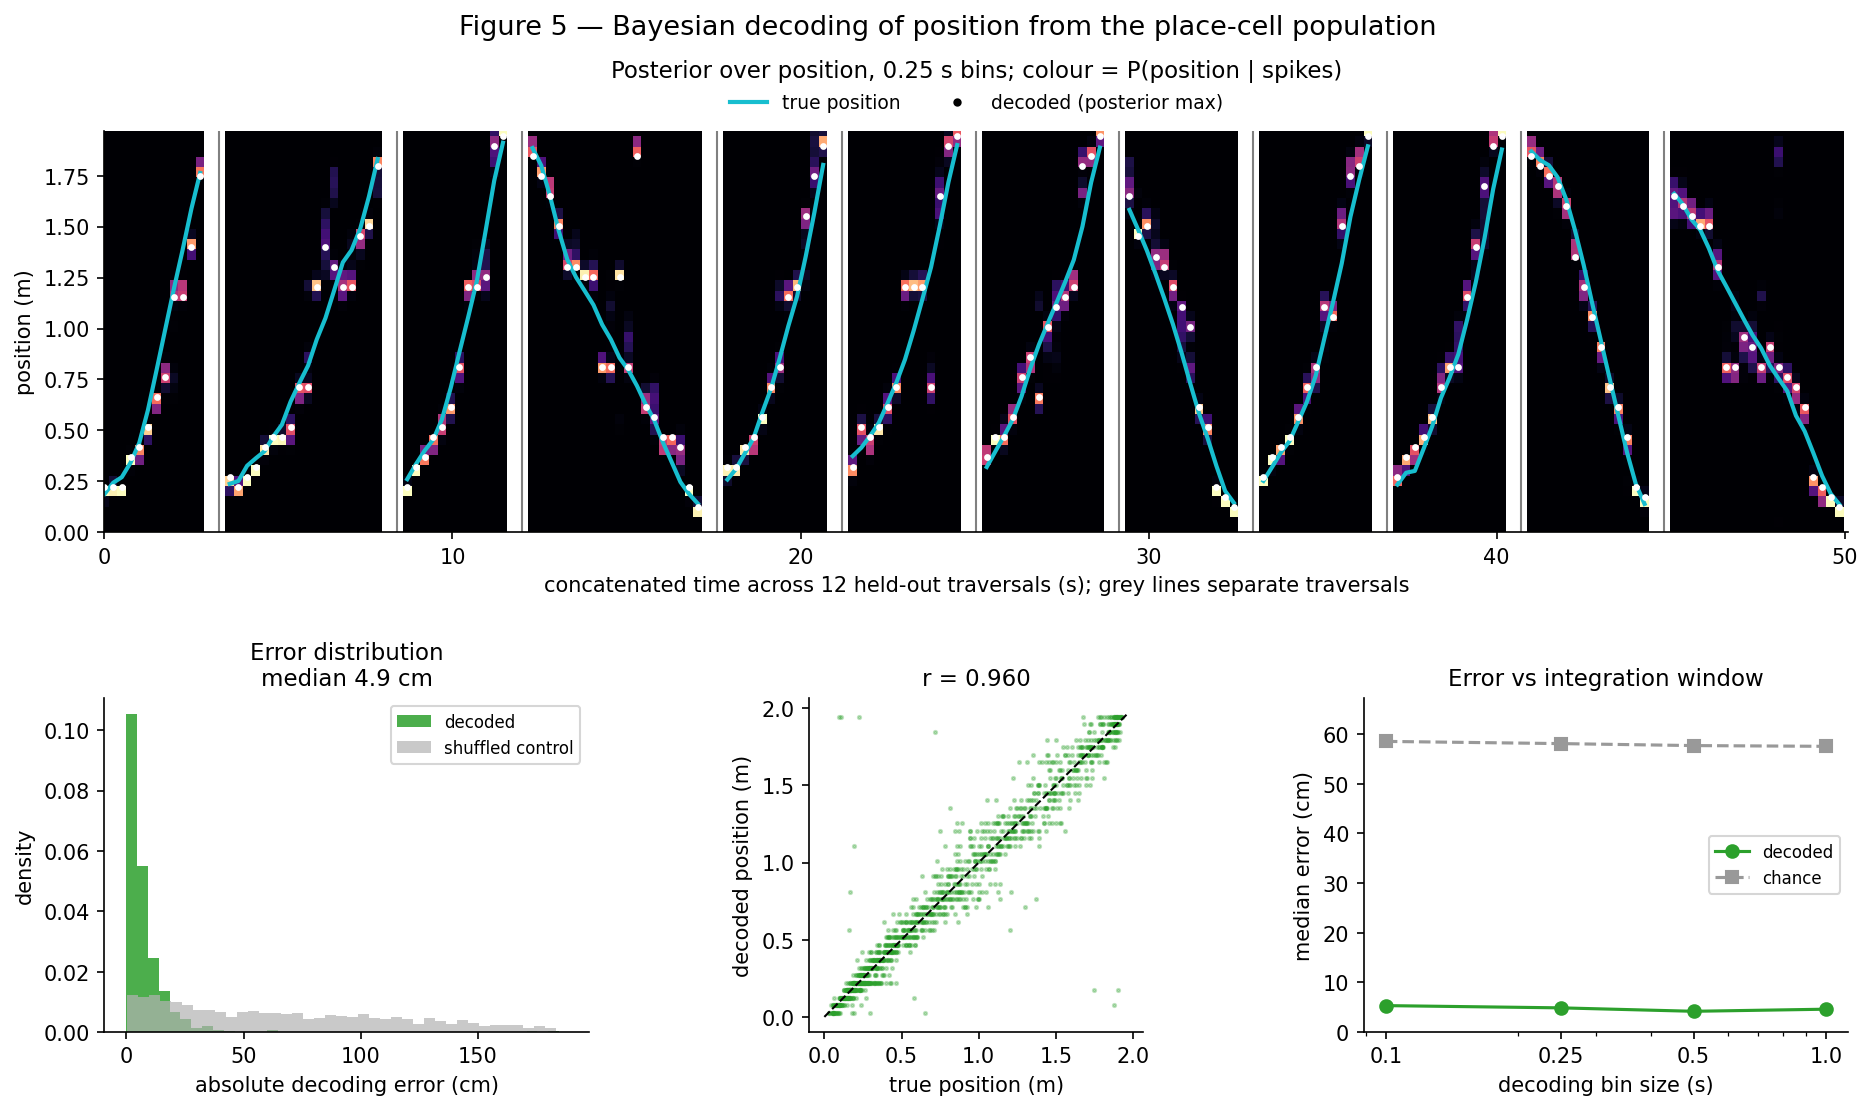

'./fig05_decoding.png'

In [16]:
d25 = dec[0.25]
fold = int(np.argmax([len(p) for p in d25["pieces"]]))
prob = np.asarray(d25["probs"][fold])
decoded = d25["pieces"][fold]
te = d25["test_eps"][fold]
truth_all = sess["position"].interpolate(decoded)
centers = np.linspace(0, sess["extent"], N_POSITION_BINS)

# Held-out traversals are not adjacent in time, so lay the longest ones out
# side by side on a concatenated axis with a separator between them.
durations = te.end - te.start
chosen = np.argsort(-durations)[:12]
chosen = chosen[np.argsort(te.start[chosen])]
seg_prob, seg_truth, seg_dec, seg_x, boundaries = [], [], [], [], []
cursor = 0.0
for i in chosen:
    m = (decoded.t >= te.start[i]) & (decoded.t <= te.end[i])
    k = int(m.sum())
    if k < 3:
        continue
    seg_prob.append(prob[m])
    seg_truth.append(truth_all.values[m])
    seg_dec.append(decoded.values[m])
    seg_x.append(cursor + np.arange(k) * d25["bin_size"])
    cursor += k * d25["bin_size"]
    boundaries.append(cursor)
    cursor += 0.6  # visual gap between traversals

fig = plt.figure(figsize=(15, 7.8))
gs = GridSpec(2, 3, figure=fig, height_ratios=[1.2, 1.0], hspace=0.45, wspace=0.3)

ax = fig.add_subplot(gs[0, :])
for x, pr, tr, dc in zip(seg_x, seg_prob, seg_truth, seg_dec):
    ax.pcolormesh(x, centers, pr.T, cmap="magma", shading="nearest", vmin=0,
                  vmax=np.percentile(prob, 99.5))
    ax.plot(x, tr, color="tab:cyan", lw=2)
    ax.plot(x, dc, ".", ms=4.5, color="w")
for b in boundaries[:-1]:
    ax.axvline(b + 0.3, color="0.5", lw=1)
ax.plot([], [], color="tab:cyan", lw=2, label="true position")
ax.plot([], [], ".", ms=6, color="k", label="decoded (posterior max)")
ax.set_xlim(0, cursor - 0.6)
ax.set_ylim(0, sess["extent"])
ax.set_ylabel("position (m)")
ax.set_xlabel("concatenated time across 12 held-out traversals (s); "
              "grey lines separate traversals")
ax.set_title("Posterior over position, 0.25 s bins; colour = P(position | spikes)", pad=26)
ax.legend(fontsize=9, loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=2,
          frameon=False)

ax = fig.add_subplot(gs[1, 0])
ax.hist(d25["error"] * 100, bins=40, color="tab:green", alpha=0.85, density=True,
        label="decoded")
ax.hist(d25["chance"] * 100, bins=40, color="0.7", alpha=0.7, density=True,
        label="shuffled control")
ax.set_xlabel("absolute decoding error (cm)"); ax.set_ylabel("density")
ax.set_title(f"Error distribution\nmedian {np.median(d25['error'])*100:.1f} cm")
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, 1])
ax.plot(d25["truth"], d25["decoded"], ".", ms=3, alpha=0.3, color="tab:green")
ax.plot([0, sess["extent"]], [0, sess["extent"]], "k--", lw=1)
ax.set_xlabel("true position (m)"); ax.set_ylabel("decoded position (m)")
ax.set_aspect("equal")
ax.set_title(f"r = {np.corrcoef(d25['decoded'], d25['truth'])[0,1]:.3f}")

ax = fig.add_subplot(gs[1, 2])
bss = list(dec)
med = [np.median(dec[b]["error"]) * 100 for b in bss]
ch = [np.median(dec[b]["chance"]) * 100 for b in bss]
ax.plot(bss, med, "o-", color="tab:green", label="decoded")
ax.plot(bss, ch, "s--", color="0.6", label="chance")
ax.set_xscale("log")
ax.set_ylim(0, max(ch) * 1.15)
ax.set_xticks(bss); ax.set_xticklabels([str(b) for b in bss])
ax.set_xlabel("decoding bin size (s)"); ax.set_ylabel("median error (cm)")
ax.set_title("Error vs integration window")
ax.legend(fontsize=8)

fig.suptitle("Figure 5 — Bayesian decoding of position from the place-cell population",
             y=0.98, fontsize=13)
savefig(fig, "fig05_decoding.png")

## 6. Is it really position, or just running speed?

On a linear track speed covaries strongly with position: the rat accelerates away from one
reward platform and decelerates into the other, so a purely speed-tuned neuron would produce
a symmetric, place-field-like rate map. We separate the two with Poisson GLMs (NeMoS) fitted
to 100 ms spike counts: a speed-only model, a position-only model, and a model with both,
each scored by held-out McFadden pseudo-$R^2$ on interleaved laps.

In [17]:
MAX_SPEED = 1.5


def per_neuron_pseudo_r2(y, mu, mu_null):
    ll = poisson.logpmf(y, np.maximum(mu, 1e-9)).sum(axis=0)
    ll0 = poisson.logpmf(y, np.maximum(mu_null, 1e-9)).sum(axis=0)
    return 1.0 - ll / ll0


def fit_glm_models(sess, spikes, ep, bin_size=0.1, n_pos_basis=15, n_speed_basis=6,
                   reg_strength=1e-3):
    counts = spikes.count(bin_size, ep=ep)
    pos = sess["position"].interpolate(counts, ep=ep)
    spd = np.clip(sess["speed"].interpolate(counts, ep=ep), 0, MAX_SPEED)

    pos_basis = nmo.basis.BSplineEval(n_basis_funcs=n_pos_basis,
                                      bounds=(0.0, sess["extent"]), label="position")
    spd_basis = nmo.basis.BSplineEval(n_basis_funcs=n_speed_basis,
                                      bounds=(0.0, MAX_SPEED), label="speed")
    designs = {"speed": (spd_basis, (spd,)),
               "position": (pos_basis, (pos,)),
               "position+speed": (pos_basis + spd_basis, (pos, spd))}

    y = np.asarray(counts)
    t = counts.t
    member = np.stack([(t >= ep.start[i]) & (t <= ep.end[i]) for i in range(len(ep))])
    idx = np.arange(len(ep))
    folds = [(idx[0::2], idx[1::2]), (idx[1::2], idx[0::2])]

    # A unit silent in one fold gives an infinite intercept at initialization
    m0, m1 = member[folds[0][0]].any(axis=0), member[folds[0][1]].any(axis=0)
    keep = (y[m0].sum(axis=0) >= 10) & (y[m1].sum(axis=0) >= 10)
    y = y[:, keep]

    scores = {k: np.zeros((y.shape[1], 2)) for k in designs}
    fitted = {}
    for f, (tr, te) in enumerate(folds):
        m_tr, m_te = member[tr].any(axis=0), member[te].any(axis=0)
        mu_null = np.repeat(y[m_tr].mean(axis=0)[None, :], m_te.sum(), axis=0)
        for name, (basis, inputs) in designs.items():
            X = np.asarray(basis.compute_features(*inputs))
            model = nmo.glm.PopulationGLM(regularizer="Ridge",
                                          regularizer_strength=reg_strength,
                                          solver_name="LBFGS")
            model.fit(X[m_tr], y[m_tr])
            scores[name][:, f] = per_neuron_pseudo_r2(
                y[m_te], np.asarray(model.predict(X[m_te])), mu_null)
            if f == 0:
                fitted[name] = (model, basis)
    return dict(scores={k: v.mean(axis=1) for k, v in scores.items()}, fitted=fitted,
                bin_size=bin_size, unit_ids=np.asarray(list(spikes.keys()))[keep],
                keep=keep)


glm = fit_glm_models(sess, exc, mov["rightward"])
for k, v in glm["scores"].items():
    print(f"{k:16s} held-out pseudo-R2: median {np.median(v):.4f}, mean {v.mean():.4f}")
gain = glm["scores"]["position+speed"] - glm["scores"]["speed"]
print(f"\nadding position improves on speed alone for {(gain > 0).sum()}/{len(gain)} units "
      f"(median gain {np.median(gain):.4f})")

speed            held-out pseudo-R2: median 0.0365, mean 0.0504
position         held-out pseudo-R2: median 0.1233, mean 0.1473
position+speed   held-out pseudo-R2: median 0.1235, mean 0.1574

adding position improves on speed alone for 100/107 units (median gain 0.0898)


saved ./fig06_glm.png


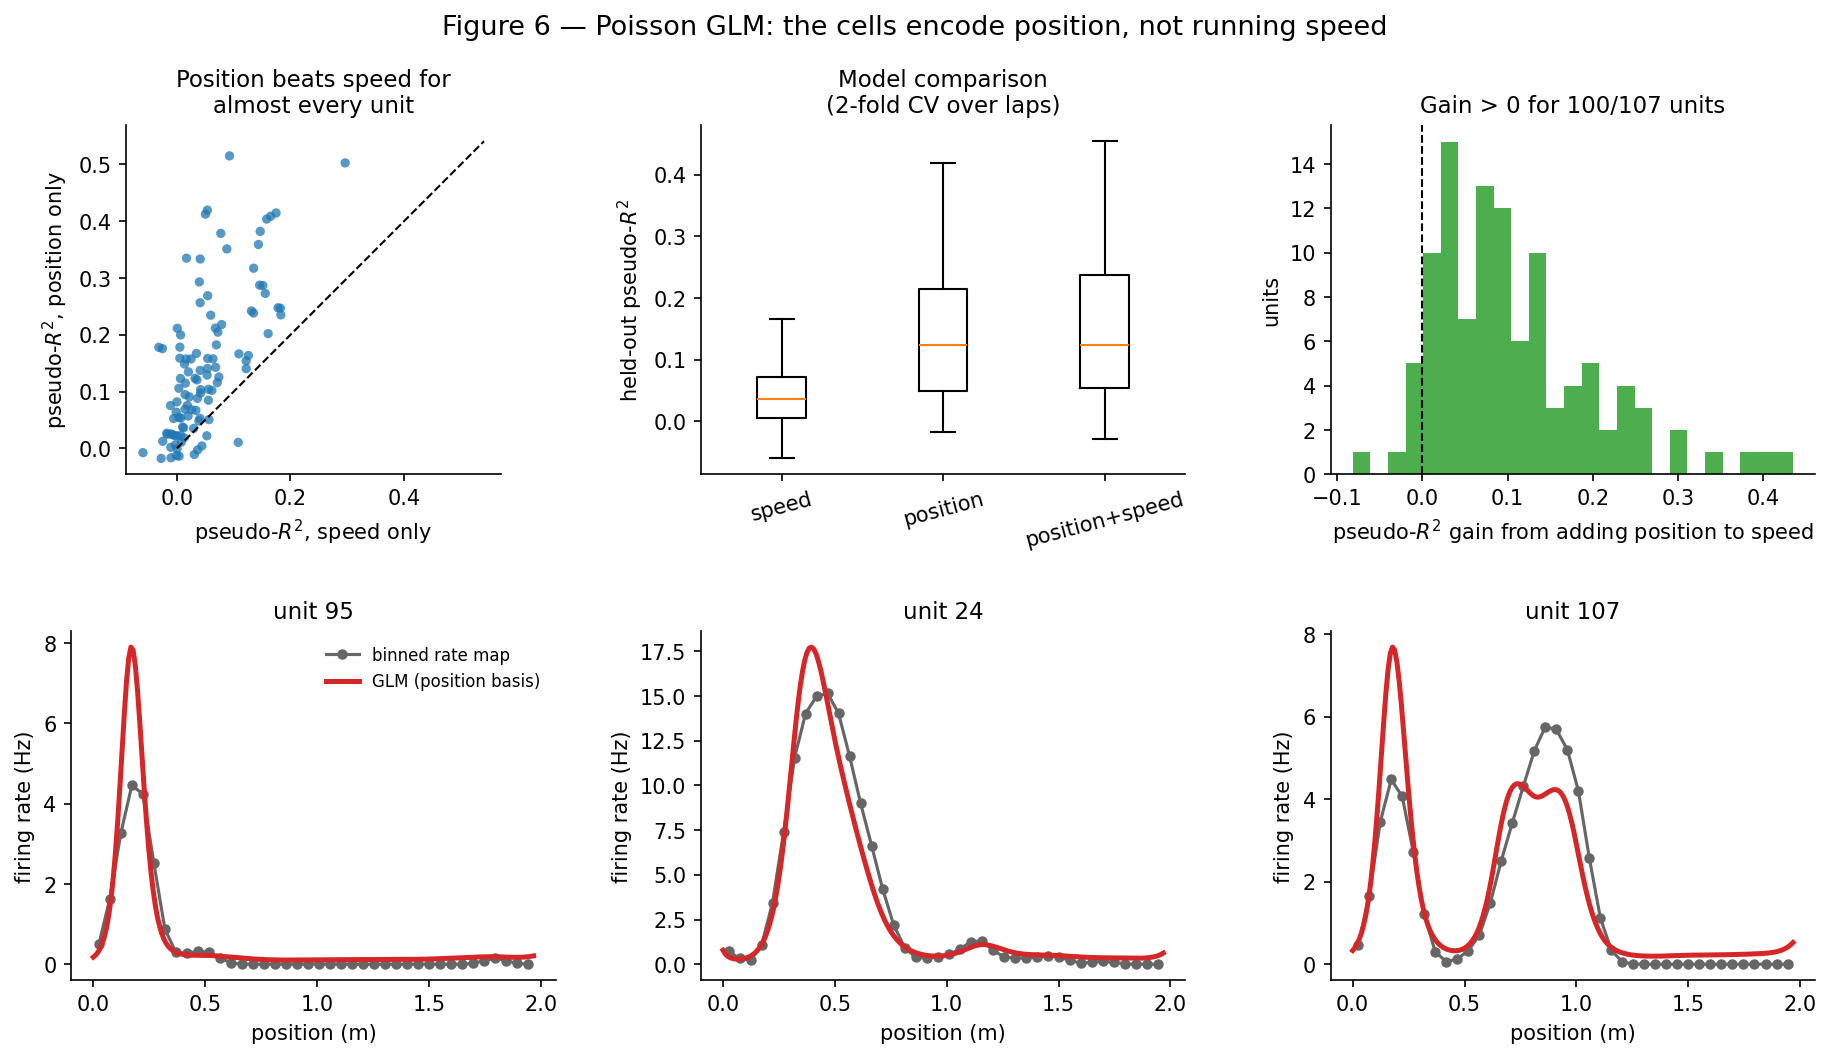

'./fig06_glm.png'

In [18]:
model, basis = glm["fitted"]["position"]
grid, basis_vals = basis.evaluate_on_grid(200)
glm_rate = np.asarray(model.predict(np.asarray(basis_vals))) / glm["bin_size"]
grid_m = np.asarray(grid).ravel()
grid_m = grid_m * sess["extent"] / grid_m.max()

fig = plt.figure(figsize=(15, 7.4))
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)

ax = fig.add_subplot(gs[0, 0])
ax.scatter(glm["scores"]["speed"], glm["scores"]["position"], s=20, alpha=0.75,
           color="tab:blue", edgecolors="none")
m = max(glm["scores"]["position"].max(), glm["scores"]["speed"].max()) * 1.05
ax.plot([0, m], [0, m], "k--", lw=1)
ax.set_xlabel("pseudo-$R^2$, speed only"); ax.set_ylabel("pseudo-$R^2$, position only")
ax.set_title("Position beats speed for\nalmost every unit")
ax.set_aspect("equal")

ax = fig.add_subplot(gs[0, 1])
labels = list(glm["scores"])
ax.boxplot([glm["scores"][k] for k in labels], tick_labels=labels, showfliers=False)
ax.set_ylabel("held-out pseudo-$R^2$")
ax.set_title("Model comparison\n(2-fold CV over laps)")
ax.tick_params(axis="x", rotation=15)

ax = fig.add_subplot(gs[0, 2])
ax.hist(gain, bins=25, color="tab:green", alpha=0.85)
ax.axvline(0, color="k", ls="--", lw=1)
ax.set_xlabel("pseudo-$R^2$ gain from adding position to speed")
ax.set_ylabel("units")
ax.set_title(f"Gain > 0 for {(gain>0).sum()}/{len(gain)} units")

glm_uid_to_col = {int(u): i for i, u in enumerate(glm["unit_ids"])}
show = [u for u in example_uids[:3] if int(u) in glm_uid_to_col]
for k, uid in enumerate(show):
    ax = fig.add_subplot(gs[1, k])
    j = int(np.where(res_r["unit_ids"] == uid)[0][0])
    ax.plot(res_r["centers"], res_r["maps"][j], "o-", ms=4, color="0.4",
            label="binned rate map")
    ax.plot(grid_m, glm_rate[:, glm_uid_to_col[int(uid)]], lw=2.4, color="tab:red",
            label="GLM (position basis)")
    ax.set_xlabel("position (m)"); ax.set_ylabel("firing rate (Hz)")
    ax.set_title(f"unit {uid}")
    if k == 0:
        ax.legend(fontsize=8, frameon=False)

fig.suptitle("Figure 6 — Poisson GLM: the cells encode position, not running speed",
             y=0.98, fontsize=13)
savefig(fig, "fig06_glm.png")

## 7. Across all five linear-track sessions

The single-session result is not a fluke of one recording. The same pipeline is applied to
every linear-track session of the dandiset.

In [19]:
all_results = {}
rows = []
for asset_id, subject, label, maze in tqdm(SESSIONS, desc="sessions"):
    a = analyze_session(asset_id, n_shuffles=300, progress=False)
    s = a["session"]
    pcs = a["is_place_cell_any"]
    group = a["exc"][[int(u) for u in a["directions"]["rightward"]["unit_ids"][pcs]]]
    d = decoding_error(s, group, a["moving"]["both"], bin_size=0.25)
    a["decoding"] = d
    all_results[label] = a
    rr = a["directions"]["rightward"]
    peak, peakpos, width = field_metrics(rr)
    rows.append(dict(
        subject=subject, session=label, maze=maze,
        track_m=round(s["extent"], 2),
        laps=a["laps"]["n_laps"]["rightward"] + a["laps"]["n_laps"]["leftward"],
        run_s=int(a["moving"]["both"].tot_length()),
        n_pyr=len(a["exc"]), n_int=len(a["inh"]),
        n_place=int(pcs.sum()), pct_place=round(100 * pcs.mean()),
        SI_pyr=round(float(np.median(rr["si"])), 2),
        SI_int=round(float(np.median(a["inhibitory"]["si"])), 3),
        width_cm=round(float(np.median(width[rr["is_place_cell"]])) * 100),
        err_cm=round(float(np.median(d["error"])) * 100, 1),
        chance_cm=round(float(np.median(d["chance"])) * 100, 1),
    ))
    s["io"].close()

session_table = pd.DataFrame(rows)
session_table.to_csv("session_summary.csv", index=False)
print(session_table.to_string(index=False))

totals = session_table[["n_pyr", "n_int", "n_place"]].sum()
print(f"\npooled: {totals.n_place} place cells out of {totals.n_pyr} pyramidal cells "
      f"({100*totals.n_place/totals.n_pyr:.0f}%) across "
      f"{len(session_table)} sessions and {session_table.subject.nunique()} rats")

sessions:   0%|          | 0/5 [00:00<?, ?it/s]

 subject           session        maze  track_m  laps  run_s  n_pyr  n_int  n_place  pct_place  SI_pyr  SI_int  width_cm  err_cm  chance_cm
Achilles Achilles_10252013 1.6m linear     1.97    84    320    120     17       97         81    0.79   0.032        30     4.9       58.1
   Buddy    Buddy_06272013 1.6m linear     2.58    40    212     48     20       25         52    1.21   0.035        32    10.5       78.2
  Cicero   Cicero_09012014 1.6m linear     2.11    78    515     55     18       36         65    0.52   0.018        48    11.3       62.7
  Cicero   Cicero_09172014   2m linear     2.27    57    412     59     13       35         59    0.58   0.025        51     9.5       66.6
  Gatsby   Gatsby_08022013 1.6m linear     2.04    82    383     66     14       39         59    0.78   0.022        38     7.3       65.1

pooled: 232 place cells out of 348 pyramidal cells (67%) across 5 sessions and 4 rats


saved ./fig07_across_sessions.png


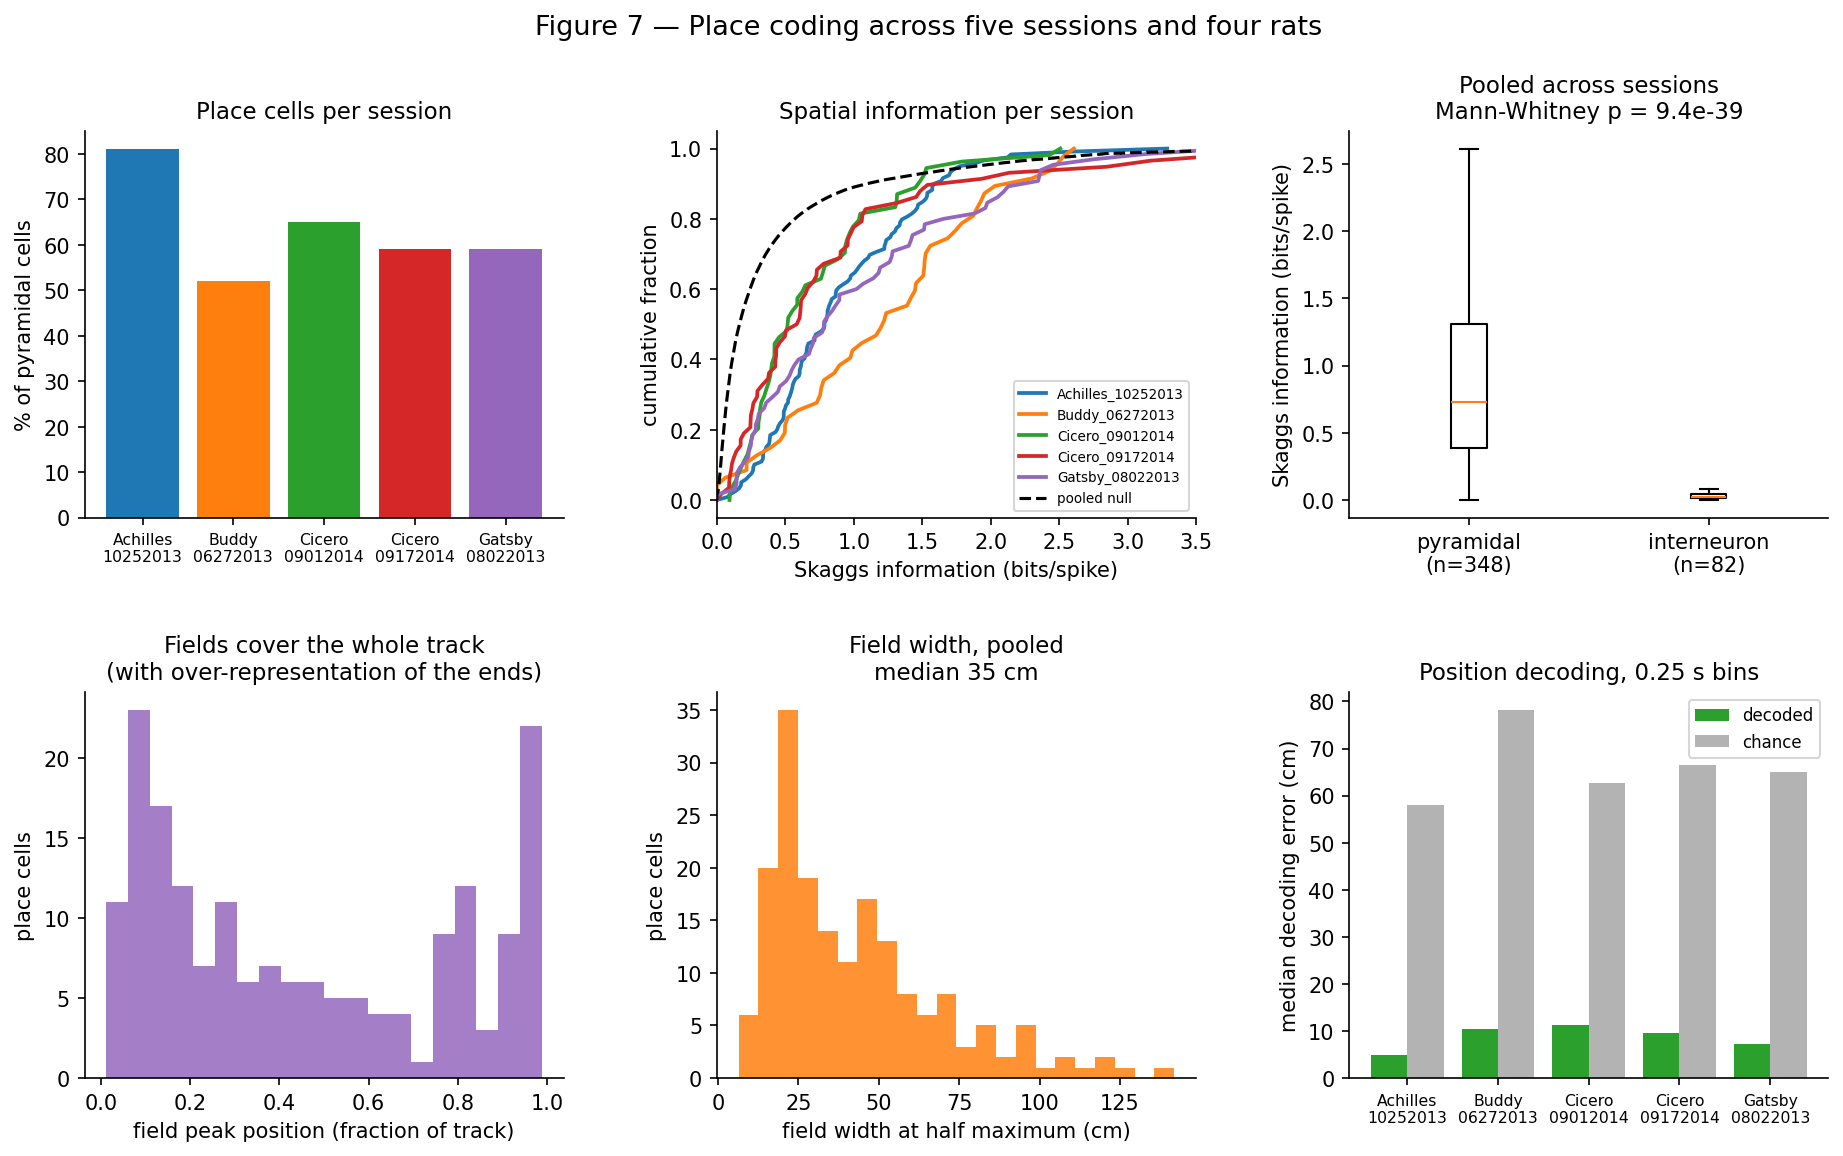

'./fig07_across_sessions.png'

In [20]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8.2))
fig.subplots_adjust(hspace=0.45, wspace=0.32)
labels = list(all_results)
colors = plt.cm.tab10(np.arange(len(labels)))

ax = axs[0, 0]
ax.bar(range(len(labels)), session_table.pct_place, color=colors)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels([l.replace("_", "\n") for l in labels], fontsize=7.5)
ax.set_ylabel("% of pyramidal cells")
ax.set_title("Place cells per session")

ax = axs[0, 1]
for c, lab in zip(colors, labels):
    si = all_results[lab]["directions"]["rightward"]["si"]
    ax.plot(np.sort(si), np.linspace(0, 1, len(si)), color=c, lw=1.8, label=lab)
null_pool = np.concatenate([all_results[l]["directions"]["rightward"]["null"].ravel()
                            for l in labels])
ax.plot(np.sort(null_pool), np.linspace(0, 1, len(null_pool)), color="k", ls="--",
        lw=1.5, label="pooled null")
ax.set_xlim(0, 3.5)
ax.set_xlabel("Skaggs information (bits/spike)"); ax.set_ylabel("cumulative fraction")
ax.set_title("Spatial information per session")
ax.legend(fontsize=6.5, loc="lower right")

ax = axs[0, 2]
pyr = np.concatenate([all_results[l]["directions"]["rightward"]["si"] for l in labels])
intn = np.concatenate([all_results[l]["inhibitory"]["si"] for l in labels])
ax.boxplot([pyr, intn], tick_labels=[f"pyramidal\n(n={len(pyr)})",
                                     f"interneuron\n(n={len(intn)})"], showfliers=False)
u, p = mannwhitneyu(pyr, intn)
ax.set_ylabel("Skaggs information (bits/spike)")
ax.set_title(f"Pooled across sessions\nMann-Whitney p = {p:.1e}")

ax = axs[1, 0]
allpos = []
for lab in labels:
    a = all_results[lab]
    rr = a["directions"]["rightward"]
    _, pp, _ = field_metrics(rr)
    allpos.append(pp[rr["is_place_cell"]] / a["session"]["extent"])
ax.hist(np.concatenate(allpos), bins=20, color="tab:purple", alpha=0.85)
ax.set_xlabel("field peak position (fraction of track)")
ax.set_ylabel("place cells")
ax.set_title("Fields cover the whole track\n(with over-representation of the ends)")

ax = axs[1, 1]
allw = []
for lab in labels:
    rr = all_results[lab]["directions"]["rightward"]
    _, _, w = field_metrics(rr)
    allw.append(w[rr["is_place_cell"]] * 100)
ax.hist(np.concatenate(allw), bins=22, color="tab:orange", alpha=0.85)
ax.set_xlabel("field width at half maximum (cm)"); ax.set_ylabel("place cells")
ax.set_title(f"Field width, pooled\nmedian {np.median(np.concatenate(allw)):.0f} cm")

ax = axs[1, 2]
x = np.arange(len(labels))
ax.bar(x - 0.2, session_table.err_cm, 0.4, color="tab:green", label="decoded")
ax.bar(x + 0.2, session_table.chance_cm, 0.4, color="0.7", label="chance")
ax.set_xticks(x)
ax.set_xticklabels([l.replace("_", "\n") for l in labels], fontsize=7.5)
ax.set_ylabel("median decoding error (cm)")
ax.set_title("Position decoding, 0.25 s bins")
ax.legend(fontsize=8)

fig.suptitle("Figure 7 — Place coding across five sessions and four rats",
             y=0.975, fontsize=13)
savefig(fig, "fig07_across_sessions.png")

## 8. Summary

Streaming five linear-track sessions from DANDI:000044 and applying a standard place-field
pipeline reproduces the defining properties of hippocampal place cells:

* **Spatial selectivity.** A majority of putative CA1 pyramidal cells fire in a restricted
  portion of the track, with median Skaggs information well above a circular-shift null.
  Simultaneously recorded interneurons carry roughly an order of magnitude less spatial
  information, so the effect is not a trivial consequence of the behaviour.
* **Reliability.** Rate maps built from odd and even laps agree closely, and the lap-by-lap
  rasters show the same cell firing at the same place on traversal after traversal.
* **Directionality.** On a linear track, fields are direction-specific: sorting cells by
  their rightward field peak leaves the leftward maps essentially unordered.
* **Population code.** Fields tile the entire track, and a Bayesian decoder recovers the
  rat's position from a quarter-second of population spiking to within a few centimetres,
  against a chance error of more than half a metre.
* **Position, not speed.** A Poisson GLM with a position basis substantially outperforms one
  built on running speed, and adding position to a speed model improves held-out likelihood
  for nearly every unit, so the spatial tuning is not an artefact of the speed profile.

Two properties of these particular NWB files are worth flagging for anyone reusing them: the
behavioural `SpatialSeries` store the sampling period in the `rate` field, and the provided
linearized position series covers only a minority of frames. Both are handled explicitly
above.